In [1]:

import xarray as xr
from matplotlib import pyplot as plt
import xarray as xr
from scipy.stats import wasserstein_distance
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
sys.path.insert(
    1, "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation"
)
import plot_utils as plot
import distribution_analysis as dist

import numpy as np
dist_folder = '/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/distributions'

In [10]:
model_idx=3
model_short_names = ['z64-MM','z128-MM','z256-MM','z64-H']
model_short_name = model_short_names[model_idx]

selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
print(f'Evaluating model: {selected_model_past["model_name"]}')
selected_model_past_ukesm=plot.PAST_MODELS_UKESM[model_idx]
selected_model_future_ukesm=plot.FUTURE_MODELS_UKESM[model_idx]

base_save_folder_past = selected_model_past['plot_folder']
base_save_folder_future = selected_model_future['plot_folder']

NG_past_forecasts =xr.open_zarr(selected_model_past['forecasts'], decode_timedelta=True).astype(np.float32)
NG_future_forecasts = xr.open_zarr(selected_model_future['forecasts'], decode_timedelta=True).astype(np.float32)

NG_past_truth = xr.open_zarr(selected_model_past['ground_truth']).astype(np.float32)
NG_future_truth = xr.open_zarr(selected_model_future['ground_truth']).astype(np.float32)

UKESM_past_forecasts =xr.open_zarr(selected_model_past_ukesm['forecasts'], decode_timedelta=True).astype(np.float32)
UKESM_future_forecasts = xr.open_zarr(selected_model_future_ukesm['forecasts'], decode_timedelta=True).astype(np.float32)

UKESM_past_truth = xr.open_zarr(selected_model_past_ukesm['ground_truth']).astype(np.float32).sel(time=slice("2011", "2014"))
UKESM_future_truth = xr.open_zarr(selected_model_future_ukesm['ground_truth']).astype(np.float32)

NG_train = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative/fields.zarr').astype(np.float32)
NG_train = NG_train.sel(time=slice("1990", "2015"))
    
UKESM_train = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/global_1985_2014_equiangular_wp_conservative_40_chunks/fields.zarr').astype(np.float32)
UKESM_train = UKESM_train.sel(time=slice("1985", "2010"))

Evaluating model: NextGEMS z64 Hierarchical


In [11]:
def create_folder_if_not_exists(folder):
    from pathlib import Path
    Path(folder).mkdir(parents=True, exist_ok=True)

In [12]:
create_folder_if_not_exists(base_save_folder_past)
create_folder_if_not_exists(base_save_folder_future)

# Calculate the dist shift between train, T1 and T2 truth

In [ ]:
save_path = '/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/hist_future_dist_shift_new/'
create_folder_if_not_exists(save_path)
# steps=[6, 48]#, 5*24, 10*24]
num_vars = len(plot.KEY_VARIABLES)

# for var_index in range(num_vars):
for var_index in range(1):
    display_name, unit, variable, plevel, _ = plot.KEY_VARIABLES[var_index]
    print(f'Processing var {display_name} ({var_index+1}/{num_vars})')
        
    # if plevel:
    #     past_train_NG=NG_train.sel(level=plevel)[variable]
    #     past_test = NG_past_truth.sel(level=plevel)[variable]
    #     future=NG_future_truth.sel(level=plevel)[variable]
    # else:
    #     past_train_NG=NG_train[variable]
    #     past_test = NG_past_truth[variable]
    #     future=NG_future_truth[variable]

    
    # train_dist_NG = calc_single_dist_with_nans(past_train_NG)
    # past_test_dist = calc_single_dist_with_nans(past_test)
    # future_test_dist_NG = calc_single_dist_with_nans(future)
    train_dist_NG = dist.load_dist(variable, dataset='N',dataslice_name='TR', is_ground_truth=True)
    past_test_dist = dist.load_dist(variable, dataset='N',dataslice_name='T1', is_ground_truth=True)
    future_test_dist_NG = dist.load_dist(variable, dataset='N',dataslice_name='T2', is_ground_truth=True)
    train_dist_NG['label'] = 'N_TR'
    past_test_dist['label'] = 'N_T1'
    future_test_dist_NG['label'] = 'N_T2'
    train_dist_NG['label_full'] = 'Train 1990-2015 (N_TR)'
    past_test_dist['label_full'] = 'Test 2016-2019 (N_T1)'
    future_test_dist_NG['label_full'] = 'Test 2046-2049 (N_T2)'
    colors=['grey', 'C0', 'C1']
    plot_5_quant = variable in ['u_component_of_wind','v_component_of_wind','relative_vorticity']

    # dist.precompute_and_save_distribution(train_dist_NG, f'N_TR/GT_{variable}', dist_folder)
    # dist.precompute_and_save_distribution(past_test_dist, f'N_T1/GT_{variable}', dist_folder)
    # dist.precompute_and_save_distribution(future_test_dist_NG, f'N_T2/GT_{variable}', dist_folder)
    
    
    dist.plot_distributions_with_nans([train_dist_NG,past_test_dist,future_test_dist_NG],
                                    bins=500,
                                    variable_name=display_name,
                                    unit=unit,
                                    colors=colors,
                                    title=f"NextGEMS Distribution Shift: {display_name}",
                                    save_to=save_path+f'{variable}{f"_at_{plevel}" if plevel else ""}_wide.png',
                                 plot_5_quantile=plot_5_quant,display_name=display_name, plot_size=(9,5)
                                )
    dist.plot_distributions_with_nans([train_dist_NG,past_test_dist,future_test_dist_NG],
                                    bins=500,
                                    variable_name=display_name,
                                    unit=unit,
                                    colors=colors,
                                    title=f"NextGEMS Distribution Shift: {display_name}",
                                    save_to=save_path+f'{variable}{f"_at_{plevel}" if plevel else ""}.png',
                                 plot_5_quantile=plot_5_quant,display_name=display_name, plot_size=(6,5)
                                )
    dist.plot_distributions_with_nans([train_dist_NG,past_test_dist,future_test_dist_NG],
                                    bins=500,
                                    variable_name=display_name,
                                    unit=unit,
                                    colors=colors,
                                    title=f"NextGEMS Distribution Shift: {display_name}",
                                    save_to=save_path+f'{variable}{f"_at_{plevel}" if plevel else ""}_wide.pdf',
                                 plot_5_quantile=plot_5_quant,display_name=display_name, plot_size=(9,5)
                                )
    dist.plot_distributions_with_nans([train_dist_NG,past_test_dist,future_test_dist_NG],
                                    bins=500,
                                    variable_name=display_name,
                                    unit=unit,
                                    colors=colors,
                                    title=f"NextGEMS Distribution Shift: {display_name}",
                                    save_to=save_path+f'{variable}{f"_at_{plevel}" if plevel else ""}.pdf',
                                 plot_5_quantile=plot_5_quant,display_name=display_name, plot_size=(6,5)
                                )
    

In [12]:
def load_dist(path):
    loaded = np.load(dist_folder + '/' + f'N_TR/GT_{variable}.npz')
    new_dict = {}
    for key in loaded.keys():
        new_dict[key] = loaded[key]
    return new_dict

# Plot all, but better

In [ ]:
compute = False


model_short_names = ['z64-MM','z128-MM','z256-MM','z64-H']


for model_idx in range(len(model_short_names)):
    model_short_name = model_short_names[model_idx]
    
    selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
    selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
    print(f'Evaluating model: {selected_model_past["model_name"]}')
    
    base_save_folder_past = selected_model_past['plot_folder']
    base_save_folder_future = selected_model_future['plot_folder']
    
    for past in [False, True]:
    
        selected_model = selected_model_past if past else selected_model_future
        print(selected_model['id'])
        
        save_to=base_save_folder_past+'distribution_shift_forecast/' if past else base_save_folder_future+'distribution_shift_forecast/'
        save_to='/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/distribution_shift_error/'
        save_name=f'NG_{model_short_name}_{"hist" if past else "future"}_dist_shift_all_vars_24_120_240.pdf'
        
        print(save_to+save_name)
        steps=[24, 5*24, 10*24]
        # steps=[6, 48]#, 5*24, 10*24]
        num_vars = len(plot.KEY_VARIABLES)
        precip_p99=0
        
        fig, axes = plt.subplots(nrows=num_vars, ncols=len(steps), figsize=(4*len(steps),2*num_vars), sharex=False, sharey='row')
        create_folder_if_not_exists(save_to)
        for var_index in range(num_vars):
        # for var_index in range(6,7):
            
            display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES[var_index]
            plot_5_quant = variable in ['u_component_of_wind','v_component_of_wind']
            train_dist_NG = dist.load_dist(variable, dataset='N',dataslice_name='TR', is_ground_truth=True)
            train_dist_NG['label'] = 'N_TR'
            train_dist_NG['label_full'] = 'N_TR'
            
            print(f'Processing var {display_name} ({var_index+1}/{num_vars})')
                  
            for i, hours_into_future in enumerate(steps):
                print(f'    Calculating distribution {i+1} of {len(steps)}')
                ax = axes[var_index, i]
    
                if compute:
                    NG_past_forecasts =xr.open_zarr(selected_model_past['forecasts'], decode_timedelta=True).astype(np.float32)
                    NG_future_forecasts = xr.open_zarr(selected_model_future['forecasts'], decode_timedelta=True).astype(np.float32)
                    
                    NG_past_truth = xr.open_zarr(selected_model_past['ground_truth']).astype(np.float32)
                    NG_future_truth = xr.open_zarr(selected_model_future['ground_truth']).astype(np.float32)
                    ds_test_truth, ds_test_forecast = dist.get_datasets_after(NG_past_truth, NG_past_forecasts, hours_into_future) if past else dist.get_datasets_after(NG_future_truth, NG_future_forecasts, hours_into_future) 
                            
                    truth = ds_test_truth.sel(level=plevel)[variable] if plevel else ds_test_truth[variable]
                    truth_dist = dist.calc_single_dist_with_nans(truth)
                    truth_dist['label'] = 'GT'
                    truth_dist['label_full'] = 'Ground Truth (GT)'
    
                    forecast=ds_test_forecast.sel(level=plevel)[variable] if plevel else ds_test_forecast[variable]
                    forecast_dist=dist.calc_single_dist_with_nans(forecast)
                    forecast_dist['label'] = 'FC'
                    forecast_dist['label_full'] = 'Forecast (FC)'
                    
                    
    
                    dist.precompute_and_save_distribution(truth_dist, variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=True, rollout=hours_into_future)
                    dist.precompute_and_save_distribution(forecast_dist, variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=False, rollout=hours_into_future, model_id=selected_model['id'])
                else:
                    truth_dist = dist.load_dist(variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=True, rollout=hours_into_future)
                    forecast_dist = dist.load_dist(variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=False, rollout=hours_into_future, model_id=selected_model['id'])
    
                if past:
                    truth_dist['label'] = 'N_T1'
                    truth_dist['label_full'] = 'N_T1'
                    forecast_dist['label'] = ''
                    forecast_dist['label_full'] = f'NG {model_short_name} 2016-2019'
                else:
                    truth_dist['label'] = 'N_T2'
                    truth_dist['label_full'] = 'N_T2'
                    forecast_dist['label'] = ''
                    forecast_dist['label_full'] = f'NG {model_short_name} 2046-2049'
                
                if (variable == 'total_precipitation_6hr') and i ==0:
                    precip_p99=truth_dist['p99']
                
                dist.plot_distributions_with_nans_on_axis(ax,
                                                     [truth_dist, forecast_dist],
                                                     background=[train_dist_NG],
                                                     bin_num=1000 if (variable == 'total_precipitation_6hr') else 500,
                                                     variable_name=display_name,
                                                     unit=unit,
                                                     title=f"{display_name} After {hours_into_future}h" if i==0 else f"After {hours_into_future}h",
                                                     plot_legend=False,
                                                     plot_5_quantile=plot_5_quant,plot_99_quant=(variable == 'total_precipitation_6hr'))
        
        min_x = [4.5, 225, -9999, 200, -9999,-9999,-9999,-9999]
        for var_index in range(num_vars):
            display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES[var_index]
            # collect all limits in this row
            xmins, xmaxs = [], []
            ymins, ymaxs = [], []
            for i, hours_into_future in enumerate(steps):
                ax = axes[var_index, i]
                xmin, xmax = ax.get_xlim()
                ymin, ymax = ax.get_ylim()
                xmins.append(xmin)
                xmaxs.append(xmax)
                ymins.append(ymin)
                ymaxs.append(ymax)
            # set same limits for all in row i
            row_xlim = (max(min(xmins),min_x[var_index]), max(xmaxs))
            
                # row_xlim = (max(min(xmins),min_x[var_index]), min(max(xmaxs), precip_p99))
                # axes.set_yscale('log')
            if not variable == 'total_precipitation_6hr':
                row_xlim = dist.get_xlim(display_name, dataset='ng')
    
            row_ylim = (min(ymins), max(ymaxs))
            for i, hours_into_future in enumerate(steps):
                axes[var_index, i].set_xlim(row_xlim)
                
                if variable == 'total_precipitation_6hr':
                    axes[var_index, i].set_yscale('log')
                    # axes[var_index, i].set_xlabel(f"{display_name} [{unit}], cut off at GT 99% ({precip_p99:.2f}{unit})" if unit else f"{display_name}, cut of at GT 99% ({precip_p99:.2f})")
                else:
                    axes[var_index, i].set_ylim(row_ylim)
                if i > 0:
                    axes[var_index, i].set_ylabel("")              # remove the label
                    axes[var_index, i].tick_params(labelleft=False)  # remove tick labels
                # axes[var_index, i].tick_params(bottom=True, top=False)
                # axes[var_index, i].xaxis.get_major_ticks()[0].set_visible(False)      # hide the leftmost tick
                # axes[var_index, i].xaxis.get_major_ticks()[-1].set_visible(False)     # hide the rightmost tick
                from matplotlib.ticker import ScalarFormatter
                offset = axes[var_index, i].xaxis.get_offset_text()
                offset.set_fontsize(9)
                
                # axes[var_index, i].xaxis.set_major_formatter(formatter)
                axes[var_index, i].ticklabel_format(axis="x", style="sci", scilimits=(-2, 3))
                if i ==0 and not 'precipitation' in display_name.lower():
                    axes[var_index, i].ticklabel_format(axis="y", style="sci", scilimits=(-2, 3))
                    offset = axes[var_index, i].yaxis.get_offset_text()
                    offset.set_x(-0.12)
                    offset.set_fontsize(9)
        fig.suptitle(f"NextGEMS {'N_T1' if past else 'N_T2'}:\n{model_short_name}", fontsize=16, y=0.96)
        from matplotlib.patches import Patch
        
        legend_elements = [
            Patch(facecolor="gray", edgecolor="none", label="Train NG 1990–2015 (N_TR)"),
            Patch(facecolor="C0", edgecolor="none", label="Test NG 2016–2019 (N_T1)" if past else "Test NG 2046–2049 (N_T2)")
        ]
        from matplotlib.lines import Line2D
        abbrev='N_T1' if past else 'N_T2'
        legend_elements += [
            Line2D([0], [0], color="C0",linestyle=(0, (1, 0)), lw=2, label=f"{abbrev} mean"),
            Line2D([0], [0], color="C0", lw=2, linestyle=(0, (1, 3)), label=f"{abbrev} 95th % (99.9th % for Precipitation)"),
            Line2D([0], [0], color="C0", lw=2, linestyle=(0, (5, 3)), label=f"{abbrev} 5th %")
        ]
            
        
        fig.legend(
            handles=legend_elements,
            loc="upper left",
            bbox_to_anchor=(0.04, 0.99),
        )

        
        legend_elements = [
            Patch(facecolor="C1", edgecolor="none", label="Forecast 2016–2019" if past else "Forecast 2046–2049")
        ]

        legend_elements += [
            Line2D([0], [0], color="C1",linestyle=(0, (1, 0)), lw=2, label="Forecast mean"),
            Line2D([0], [0], color="C1", lw=2, linestyle=(0, (1, 3)), label="Forecast 95th % (99.9th % for Precipitation)"),
            Line2D([0], [0], color="C1", lw=2, linestyle=(0, (5, 3)), label="Forecast 5th %")
        ]
            
        
        fig.legend(
            handles=legend_elements,
            loc="upper right",
            bbox_to_anchor=(0.98, 0.99),
        )
        
        fig.tight_layout(rect=[0, 0, 1, 0.96])
        plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
        plt.show()

In [2]:

ukesm_2046 = xr.open_zarr('/hkfs/work/workspace/scratch/xo8179-ukesm/regridded/ht_1_2046_2049.zarr')

In [ ]:
rename_vars = { "ht_1": "geopotential_500" }
ukesm_2046 = ukesm_2046.rename(rename_vars)

In [5]:
ukesm_geopot_2046 = ukesm_2046['geopotential_500'].squeeze('p', drop=True)
print(ukesm_geopot_2046)

<xarray.DataArray 'geopotential_500' (time: 5760, longitude: 128, latitude: 64)> Size: 189MB
dask.array<getitem, shape=(5760, 128, 64), dtype=float32, chunksize=(40, 128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) object 46kB 2046-01-01 00:00:00 ... 2049-12-30 18:00:00
Attributes:
    date:           01/01/15
    long_name:      Height
    name:           ht_1
    source:         Unified Model Output (Vn11.2):
    standard_name:  geopotential_height
    time:           00:00
    title:          Height
    units:          m
    valid_max:      5977.5390625
    valid_min:      4656.03125


In [6]:
ukesm_geopot_2046*=plot.UKESM_GEOPOT_CONST

In [8]:

data = dist.calc_single_dist_with_nans(ukesm_geopot_2046)

vals = data["vals"]
weights = data["weights"]

hist, edges = np.histogram(vals, bins=500, weights=weights, density=True)
data["hist"] = hist
data["bins"] = edges

ukesm_2046_geopot_data = {}
for key in data.keys():
    if key == "vals" or key == "weights":
        continue
    ukesm_2046_geopot_data[key] = data[key]


Processing var Geopotential at 500hPa (1/7)
loading N_TR/GT_geopotential.npz
loading N_T2/GT_geopotential.npz
loading U_TR/GT_geopotential_500.npz
loading U_T2/GT_geopotential_500.npz


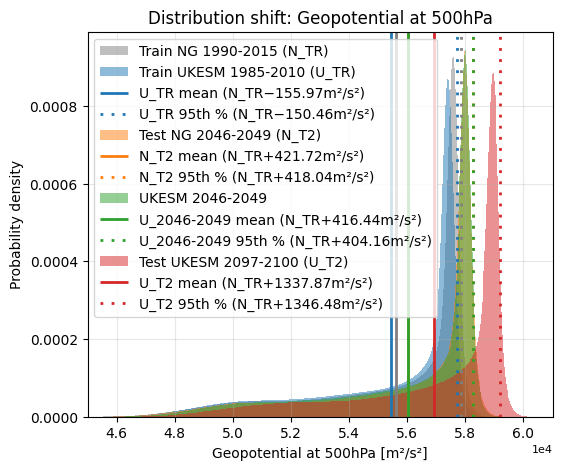

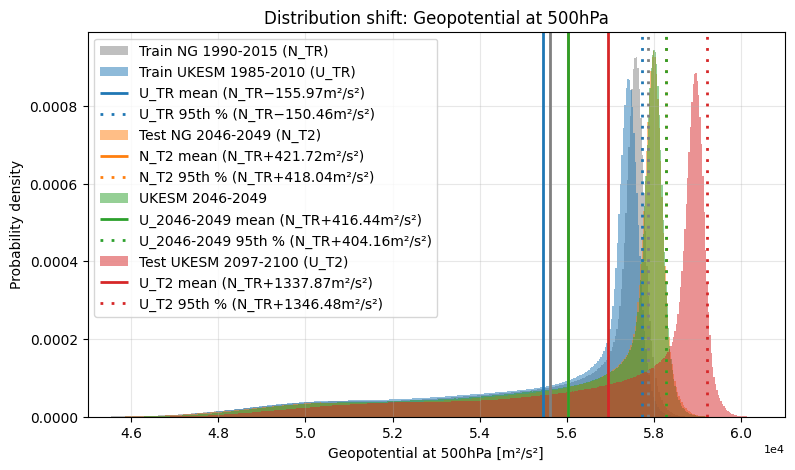

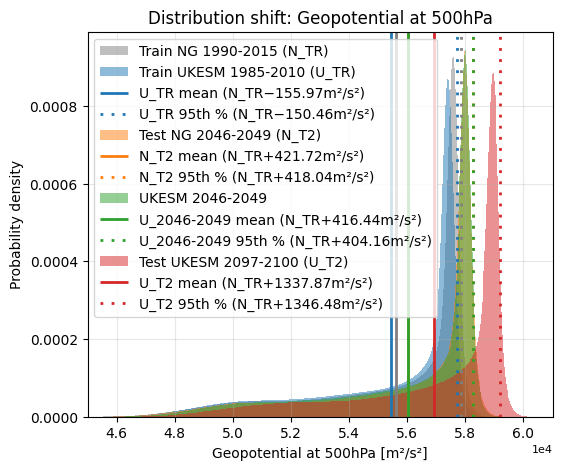

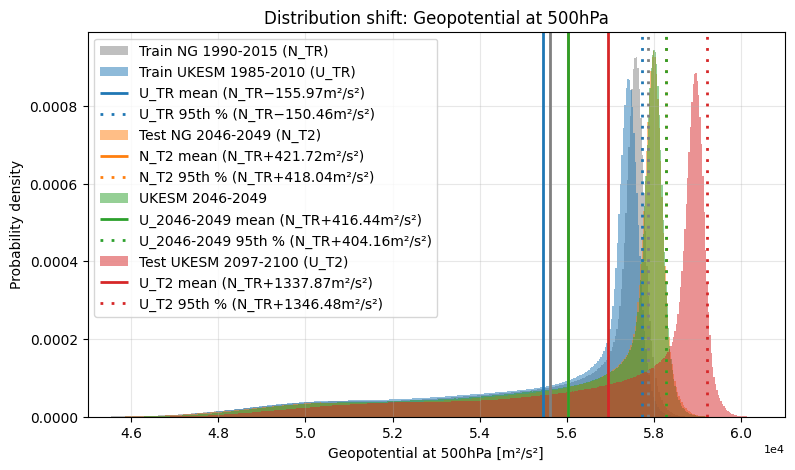

In [13]:
save_path = '/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/hist_future_dist_shift_new/'
create_folder_if_not_exists(save_path)
# steps=[6, 48]#, 5*24, 10*24]
num_vars = len(plot.KEY_VARIABLES)


# for var_index in range(num_vars):
for var_index in range(1):
    display_name, unit, variable, plevel, _ = plot.KEY_VARIABLES[var_index]
    print(f'Processing var {display_name} ({var_index+1}/{num_vars})')
        
    # if plevel:
    #     # past_train_NG=NG_train.sel(level=plevel)[variable]
    #     # past_test = NG_past_truth.sel(level=plevel)[variable]
    #     # future=NG_future_truth.sel(level=plevel)[variable]
    #     if variable == 'geopotential':
    #         past_train_UKESM=UKESM_train['geopotential_500']*plot.UKESM_GEOPOT_CONST
    #         past_test_UKESM = UKESM_past_truth['geopotential_500']*plot.UKESM_GEOPOT_CONST
    #         future_UKESM=UKESM_future_truth['geopotential_500']*plot.UKESM_GEOPOT_CONST
    #     else:
    #         past_train_UKESM=UKESM_train.sel(level=plevel)[variable]
    #         past_test_UKESM = UKESM_past_truth.sel(level=plevel)[variable]
    #         future_UKESM=UKESM_future_truth.sel(level=plevel)[variable]
    #         if plevel and plevel>500:
    #             print(f"    Applying mask... ")
    #             past_train_UKESM = plot.get_masked_ukesm_data(past_train_UKESM, plevel=plevel)
    #             past_test_UKESM = plot.get_masked_ukesm_data(past_test_UKESM, plevel=plevel)
    #             future_UKESM = plot.get_masked_ukesm_data(future_UKESM, plevel=plevel)
    # else:
    #     # past_train_NG=NG_train[variable]
    #     # past_test = NG_past_truth[variable]
    #     # future=NG_future_truth[variable]
    #     if variable == '2m_temperature':
    #         past_train_UKESM=UKESM_train['surface_temperature']
    #         past_test_UKESM = UKESM_past_truth['surface_temperature']
    #         future_UKESM=UKESM_future_truth['surface_temperature']
    #     elif variable == 'total_precipitation_6hr':
    #         past_train_UKESM=UKESM_train[variable]*plot.UKESM_PRECIP_CONST
    #         past_test_UKESM = UKESM_past_truth[variable]*plot.UKESM_PRECIP_CONST
    #         future_UKESM=UKESM_future_truth[variable]*plot.UKESM_PRECIP_CONST
    #     else:
    #         past_train_UKESM=UKESM_train[variable]
    #         past_test_UKESM = UKESM_past_truth[variable]
    #         future_UKESM=UKESM_future_truth[variable]
    ukesm_var=variable
    if variable == '2m_temperature':
        ukesm_var='surface_temperature'
    if variable == 'geopotential':
        ukesm_var='geopotential_500'

    train_dist_NG = dist.load_dist(variable, dataset='N',dataslice_name='TR', is_ground_truth=True)
    future_test_dist_NG = dist.load_dist(variable, dataset='N',dataslice_name='T2', is_ground_truth=True)
    train_dist_UKESM = dist.load_dist(ukesm_var, dataset='U',dataslice_name='TR', is_ground_truth=True)
    future_test_dist_UKESM = dist.load_dist(ukesm_var, dataset='U',dataslice_name='T2', is_ground_truth=True)
    

    
    train_dist_NG['label'] = 'N_TR'
    train_dist_NG['label_full'] = 'Train NG 1990-2015 (N_TR)'
    # past_test_dist['label'] = 'T1'
    future_test_dist_NG['label'] = 'N_T2'
    future_test_dist_NG['label_full'] = 'Test NG 2046-2049 (N_T2)'
    # past_test_dist['label_full'] = 'Test 2016-2019 (T1)'
    
    train_dist_UKESM['label'] = 'U_TR'
    train_dist_UKESM['label_full'] = 'Train UKESM 1985-2010 (U_TR)'
    future_test_dist_UKESM['label'] = 'U_T2'
    future_test_dist_UKESM['label_full'] = 'Test UKESM 2097-2100 (U_T2)'

    ukesm_2046_geopot_data['label'] = 'U_2046-2049'
    ukesm_2046_geopot_data['label_full'] = 'UKESM 2046-2049'

    # precompute_and_save_distribution(train_dist_UKESM, f'U_TR/GT_{variable}', dist_folder)
    # precompute_and_save_distribution(past_test_dist_UKESM, f'U_T1/GT_{variable}', dist_folder)
    # precompute_and_save_distribution(future_test_dist_UKESM, f'U_T2/GT_{variable}', dist_folder)
    
    colors=['grey', 'C0', 'C1', 'C2', 'C3']
    plot_5_quant = variable in ['u_component_of_wind','v_component_of_wind','relative_vorticity']
    dist.plot_distributions_with_nans([train_dist_NG,train_dist_UKESM,future_test_dist_NG,ukesm_2046_geopot_data,future_test_dist_UKESM],
                                    bins=500,
                                    variable_name=display_name,
                                    unit=unit,
                                    colors=colors,
                                    title=f"Distribution shift: {display_name}",
                                    save_to=save_path+f'{variable}{f"_at_{plevel}" if plevel else ""}_WITH_UKESM_2046.png',
                                 plot_5_quantile=plot_5_quant,display_name=display_name, plot_size=(6,5)
                                )
    dist.plot_distributions_with_nans([train_dist_NG,train_dist_UKESM,future_test_dist_NG,ukesm_2046_geopot_data,future_test_dist_UKESM],
                                    bins=500,
                                    variable_name=display_name,
                                    unit=unit,
                                    colors=colors,
                                    title=f"Distribution shift: {display_name}",
                                    save_to=save_path+f'{variable}{f"_at_{plevel}" if plevel else ""}_WITH_UKESM_wide_2046.png',
                                 plot_5_quantile=plot_5_quant,display_name=display_name, plot_size=(9,5)
                                )
    dist.plot_distributions_with_nans([train_dist_NG,train_dist_UKESM,future_test_dist_NG,ukesm_2046_geopot_data,future_test_dist_UKESM],
                                    bins=500,
                                    variable_name=display_name,
                                    unit=unit,
                                    colors=colors,
                                    title=f"Distribution shift: {display_name}",
                                    save_to=save_path+f'{variable}{f"_at_{plevel}" if plevel else ""}_WITH_UKESM_2046.pdf',
                                 plot_5_quantile=plot_5_quant,display_name=display_name, plot_size=(6,5)
                                )
    dist.plot_distributions_with_nans([train_dist_NG,train_dist_UKESM,future_test_dist_NG,ukesm_2046_geopot_data,future_test_dist_UKESM],
                                    bins=500,
                                    variable_name=display_name,
                                    unit=unit,
                                    colors=colors,
                                    title=f"Distribution shift: {display_name}",
                                    save_to=save_path+f'{variable}{f"_at_{plevel}" if plevel else ""}_WITH_UKESM_wide_2046.pdf',
                                 plot_5_quantile=plot_5_quant,display_name=display_name, plot_size=(9,5)
                                )

# Plot all, but too tiny

In [ ]:
compute = True


model_short_names = ['z64-MM','z128-MM','z256-MM','z64-H']
for model_idx in range(4):
    model_short_name = model_short_names[model_idx]
    
    selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
    selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
    print(f'Evaluating model: {selected_model_past["model_name"]}')
    
    base_save_folder_past = selected_model_past['plot_folder']
    base_save_folder_future = selected_model_future['plot_folder']
    
    for past in [False, True]:
    
        selected_model = selected_model_past if past else selected_model_future
        print(selected_model['id'])
        
        save_to=base_save_folder_past+'distribution_shift_forecast/' if past else base_save_folder_future+'distribution_shift_forecast/'
        save_to='/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/distribution_shift_error/'
        save_name=f'NG_{model_short_name}_{"hist" if past else "future"}_dist_shift_all_vars_24_120_240.pdf'
        
        print(save_to+save_name)
        steps=[24, 5*24, 10*24]
        # steps=[6, 48]#, 5*24, 10*24]
        num_vars = len(plot.KEY_VARIABLES)
        precip_p99=0
        
        fig, axes = plt.subplots(nrows=num_vars, ncols=len(steps), figsize=(6*len(steps),3*num_vars), sharex=False, sharey=False)
        create_folder_if_not_exists(save_to)
        for var_index in range(num_vars):
        # for var_index in range(6,7):
            
            display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES[var_index]
            plot_5_quant = variable in ['u_component_of_wind','v_component_of_wind']
            train_dist_NG = dist.load_dist(variable, dataset='N',dataslice_name='TR', is_ground_truth=True)
            train_dist_NG['label'] = 'N_TR'
            train_dist_NG['label_full'] = 'Train NG 1990-2015 (N_TR)'
            
            print(f'Processing var {display_name} ({var_index+1}/{num_vars})')
                  
            for i, hours_into_future in enumerate(steps):
                print(f'    Calculating distribution {i+1} of {len(steps)}')
                ax = axes[var_index, i]
    
                if compute:
                    NG_past_forecasts =xr.open_zarr(selected_model_past['forecasts'], decode_timedelta=True).astype(np.float32)
                    NG_future_forecasts = xr.open_zarr(selected_model_future['forecasts'], decode_timedelta=True).astype(np.float32)
                    
                    NG_past_truth = xr.open_zarr(selected_model_past['ground_truth']).astype(np.float32)
                    NG_future_truth = xr.open_zarr(selected_model_future['ground_truth']).astype(np.float32)
                    ds_test_truth, ds_test_forecast = dist.get_datasets_after(NG_past_truth, NG_past_forecasts, hours_into_future) if past else dist.get_datasets_after(NG_future_truth, NG_future_forecasts, hours_into_future) 
                            
                    truth = ds_test_truth.sel(level=plevel)[variable] if plevel else ds_test_truth[variable]
                    truth_dist = dist.calc_single_dist_with_nans(truth)
                    truth_dist['label'] = 'GT'
                    truth_dist['label_full'] = 'Ground Truth (GT)'
    
                    forecast=ds_test_forecast.sel(level=plevel)[variable] if plevel else ds_test_forecast[variable]
                    forecast_dist=dist.calc_single_dist_with_nans(forecast)
                    forecast_dist['label'] = 'FC'
                    forecast_dist['label_full'] = 'Forecast (FC)'
                    
                    
    
                    dist.precompute_and_save_distribution(truth_dist, variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=True, rollout=hours_into_future)
                    dist.precompute_and_save_distribution(forecast_dist, variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=False, rollout=hours_into_future, model_id=selected_model['id'])
                else:
                    truth_dist = dist.load_dist(variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=True, rollout=hours_into_future)
                    forecast_dist = dist.load_dist(variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=False, rollout=hours_into_future, model_id=selected_model['id'])
    
                if past:
                    truth_dist['label'] = 'N_T1'
                    truth_dist['label_full'] = 'Test NG 2016-2019 (N_T1)'
                    forecast_dist['label'] = ''
                    forecast_dist['label_full'] = f'NG {model_short_name} 2016-2019'
                else:
                    truth_dist['label'] = 'N_T2'
                    truth_dist['label_full'] = 'Test NG 2046-2049 (N_T2)'
                    forecast_dist['label'] = ''
                    forecast_dist['label_full'] = f'NG {model_short_name} 2046-2049'
                
                if (variable == 'total_precipitation_6hr') and i ==0:
                    precip_p99=truth_dist['p99']
                
                dist.plot_distributions_with_nans_on_axis(ax,
                                                     [truth_dist, forecast_dist],
                                                     background=[train_dist_NG],
                                                     bin_num=1000 if (variable == 'total_precipitation_6hr') else 500,
                                                     variable_name=display_name,
                                                     unit=unit,
                                                     title=f"{'N_T1' if past else 'N_T2'}: {display_name} ({model_short_name}, {hours_into_future}h)",
                                                     plot_legend=i<1,
                                                     plot_5_quantile=plot_5_quant,plot_99_quant=(variable == 'total_precipitation_6hr'))
        
        min_x = [4.5, 225, -9999, 200, -9999,-9999,-9999,-9999]
        for var_index in range(num_vars):
            display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES[var_index]
            # collect all limits in this row
            xmins, xmaxs = [], []
            ymins, ymaxs = [], []
            for i, hours_into_future in enumerate(steps):
                ax = axes[var_index, i]
                xmin, xmax = ax.get_xlim()
                ymin, ymax = ax.get_ylim()
                xmins.append(xmin)
                xmaxs.append(xmax)
                ymins.append(ymin)
                ymaxs.append(ymax)
            # set same limits for all in row i
            row_xlim = (max(min(xmins),min_x[var_index]), max(xmaxs))
            
                # row_xlim = (max(min(xmins),min_x[var_index]), min(max(xmaxs), precip_p99))
                # axes.set_yscale('log')
            if not variable == 'total_precipitation_6hr':
                row_xlim = dist.get_xlim(display_name, dataset='ng')
    
            row_ylim = (min(ymins), max(ymaxs))
            for i, hours_into_future in enumerate(steps):
                axes[var_index, i].set_xlim(row_xlim)
                
                if variable == 'total_precipitation_6hr':
                    axes[var_index, i].set_yscale('log')
                    # axes[var_index, i].set_xlabel(f"{display_name} [{unit}], cut off at GT 99% ({precip_p99:.2f}{unit})" if unit else f"{display_name}, cut of at GT 99% ({precip_p99:.2f})")
                else:
                    axes[var_index, i].set_ylim(row_ylim)
        plt.tight_layout()
        plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
        plt.show()

In [9]:
hours_into_future=240
forecast_dist = dist.load_dist(variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=False,
                               rollout=hours_into_future, model_id=plot.FUTURE_MODELS_NG_era5[0]['id'])
forecast_dist2 = dist.load_dist(variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=False,
                                rollout=hours_into_future, model_id=plot.FUTURE_MODELS_NG_era5[2]['id'])
                
print(forecast_dist['mean'])
print(forecast_dist2['mean'])

loading N_T2/FC_specific_humidity_240_z64_future.npz
loading N_T2/FC_specific_humidity_240_z256_future.npz
0.004037016724153743
0.0037322927986205372


/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/distribution_shift_error/NG_dist_shift_temperature_multiple_models_past_future_24_120_240.pdf
Evaluating model: NextGEMS z64 Multi-Mesh
z64_past
Processing var Temperature at 850hPa (2/7)
loading N_TR/GT_temperature.npz
    Calculating distribution 1 of 2
loading N_T1/GT_temperature_120.npz
loading N_T1/FC_temperature_120_z64_past.npz
    Calculating distribution 2 of 2
loading N_T2/GT_temperature_120.npz
loading N_T2/FC_temperature_120_z64_future.npz
Evaluating model: NextGEMS z256 Multi-Mesh
z256_past
Processing var Temperature at 850hPa (2/7)
loading N_TR/GT_temperature.npz
    Calculating distribution 1 of 2
loading N_T1/GT_temperature_120.npz
loading N_T1/FC_temperature_120_z256_past.npz
    Calculating distribution 2 of 2
loading N_T2/GT_temperature_120.npz
loading N_T2/FC_temperature_120_z256_future.npz
Evaluating model: NextGEMS z64 Hierarchical
z64 hierarchical_past
Processing var Temperature a

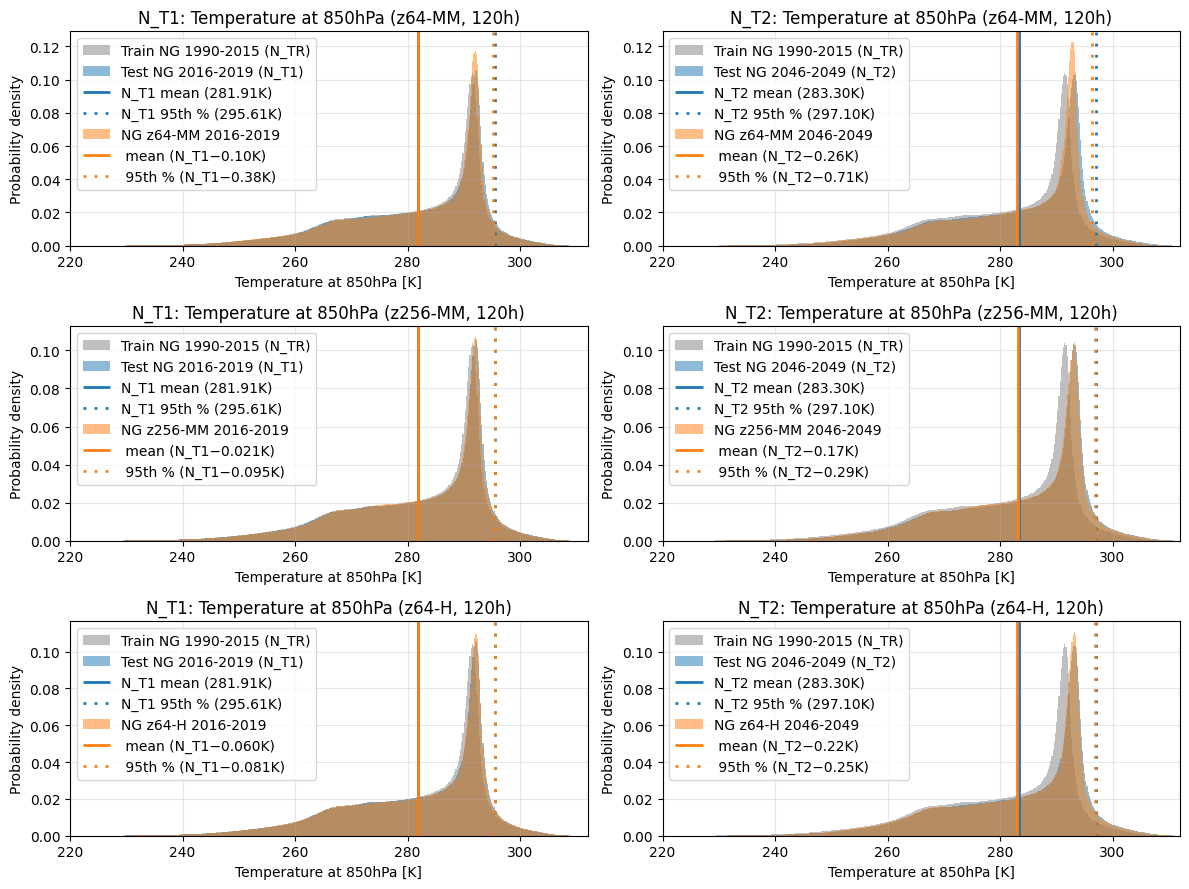

In [5]:
compute = False

model_short_names = ['z64-MM','z128-MM','z256-MM','z64-H']
model_idx=0

save_to='/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_nextgems_new/plots/distribution_shift_error/'
save_name='NG_dist_shift_temperature_multiple_models_past_future_24_120_240.pdf'
print(save_to+save_name)
steps=5*24
# steps=[6, 48]#, 5*24, 10*24]
num_vars = len(plot.KEY_VARIABLES)
precip_p99=0
nrows=3
ncols=2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols,3*nrows), sharex=False, sharey=False)
create_folder_if_not_exists(save_to)

for j, model_idx in enumerate([0,2,3]):
    model_short_name = model_short_names[model_idx]
    selected_model_past=plot.PAST_MODELS_NG_era5[model_idx]
    selected_model_future=plot.FUTURE_MODELS_NG_era5[model_idx]
    print(f'Evaluating model: {selected_model_past["model_name"]}')
    
    base_save_folder_past = selected_model_past['plot_folder']
    base_save_folder_future = selected_model_future['plot_folder']
    compute = False


    print(selected_model_past['id'])
    
    # for var_index in range(6,7):
    var_index=1
    display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES[var_index]
    plot_5_quant = variable in ['u_component_of_wind','v_component_of_wind','relative_vorticity']
    print(f'Processing var {display_name} ({var_index+1}/{num_vars})')
    train_dist_NG = dist.load_dist(variable, dataset='N',dataslice_name='TR', is_ground_truth=True)
    train_dist_NG['label'] = 'N_TR'
    train_dist_NG['label_full'] = 'Train NG 1990-2015 (N_TR)'
            
    for i, past in enumerate([True, False]):
        print(f'    Calculating distribution {i+1} of {2}')
        hours_into_future = steps
        ax = axes[j, i]
        selected_model = selected_model_past if past else selected_model_future
        
        truth_dist = dist.load_dist(variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=True, rollout=hours_into_future)
        forecast_dist = dist.load_dist(variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=False, rollout=hours_into_future, model_id=selected_model['id'])
        

        if past:
            truth_dist['label'] = 'N_T1'
            truth_dist['label_full'] = 'Test NG 2016-2019 (N_T1)'
            forecast_dist['label'] = ''
            forecast_dist['label_full'] = f'NG {model_short_name} 2016-2019'
        else:
            truth_dist['label'] = 'N_T2'
            truth_dist['label_full'] = 'Test NG 2046-2049 (N_T2)'
            forecast_dist['label'] = ''
            forecast_dist['label_full'] = f'NG {model_short_name} 2046-2049'
        if (variable == 'total_precipitation_6hr') and i ==0:
                precip_p99=truth_dist['p99']
        dist.plot_distributions_with_nans_on_axis(ax,
                                                [truth_dist, forecast_dist],
                                                background=[train_dist_NG],
                                                bin_num=1000 if (variable == 'total_precipitation_6hr') else 500,
                                                variable_name=display_name,
                                                unit=unit,
                                                title=f"{'N_T1' if past else 'N_T2'}: {display_name} ({model_short_name}, {hours_into_future}h)",
                                                plot_legend=True,
                                                plot_5_quantile=plot_5_quant,plot_99_quant=(variable == 'total_precipitation_6hr'))

    
for model_idx in range(3):
    display_name, unit, variable, plevel, _ = plot.KEY_VARIABLES[var_index]
    # collect all limits in this row
    xmins, xmaxs = [], []
    ymins, ymaxs = [], []
    for i, hours_into_future in enumerate([True, False]):
        
        ax = axes[model_idx, i]
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        print(f'{var_index}, {i}, {ax.get_ylim()}')
        xmins.append(xmin)
        xmaxs.append(xmax)
        ymins.append(ymin)
        ymaxs.append(ymax)
    # set same limits for all in row i
    row_xlim = dist.get_xlim(display_name, dataset='ng')
    row_ylim = (min(ymins), max(ymaxs))
    for i, hours_into_future in enumerate([True, False]):
        axes[model_idx, i].set_xlim(row_xlim)
        if variable == 'total_precipitation_6hr':
            axes[model_idx, i].set_yscale('log')
        else:
            axes[model_idx, i].set_ylim(row_ylim)
        # axes[var_index, i].set_ylim(row_ylim)
        # if variable == 'total_precipitation_6hr':
        #     axes[var_index, i].set_xlabel(f"{display_name} [{unit}], cut off at GT 99% ({precip_p99:.2f}{unit})" if unit else f"{display_name}, cut of at GT 99% ({precip_p99:.2f})")
plt.tight_layout()
plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)

z64 hierarchical_past
/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z64_hierarchical/plots/future/distribution_shift_forecast/dist_shift_all_vars_past_future_48_120_240.png
Processing var Geopotential at 500hPa (1/7)
    Calculating distribution 1 of 2
    Calculating distribution 2 of 2
Processing var Temperature at 850hPa (2/7)
    Calculating distribution 1 of 2
    Calculating distribution 2 of 2
Processing var Specific Humidity at 700hPa (3/7)
    Calculating distribution 1 of 2
    Calculating distribution 2 of 2
Processing var 2m Temperature (4/7)
    Calculating distribution 1 of 2
    Calculating distribution 2 of 2
Processing var U-Component of Wind at 850hPa (5/7)
    Calculating distribution 1 of 2
    Calculating distribution 2 of 2
Processing var V-Component of Wind at 850hPa (6/7)
    Calculating distribution 1 of 2
    Calculating distribution 2 of 2
Processing var Total Precip

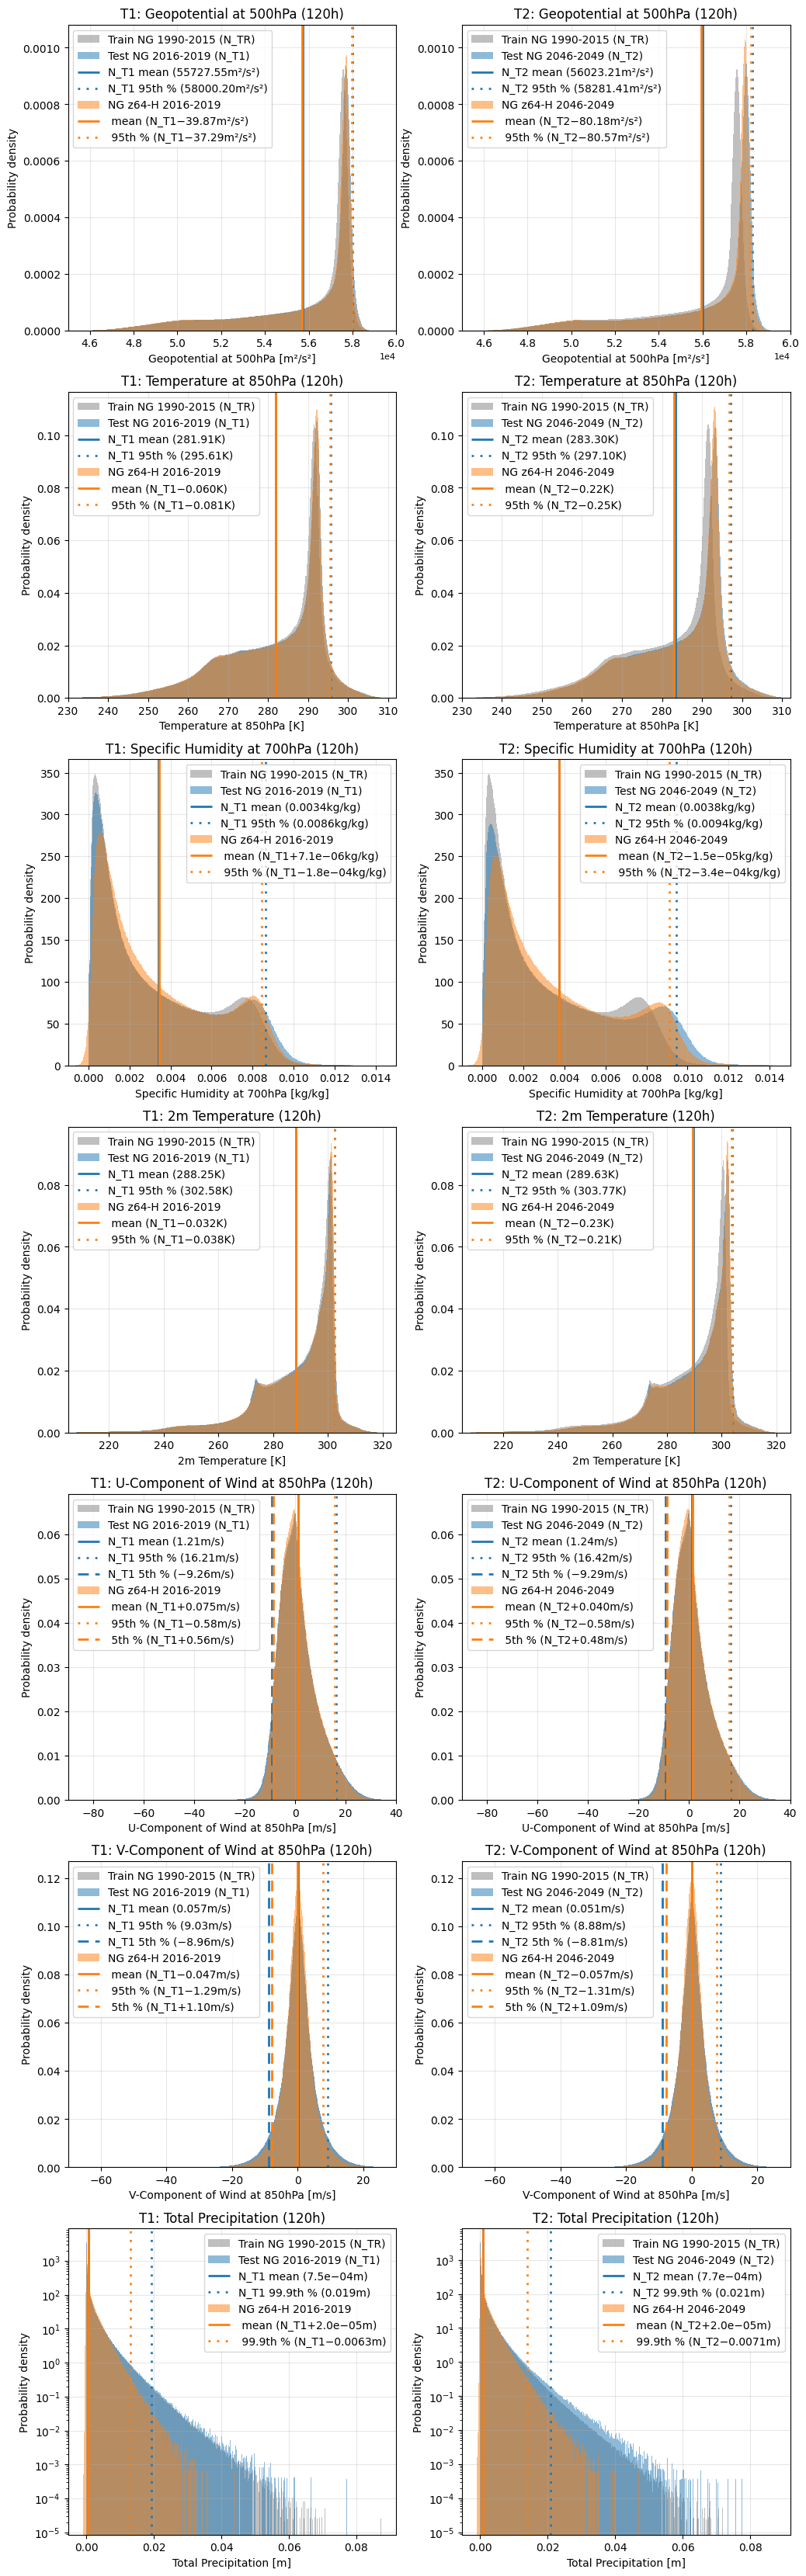

In [26]:
print(selected_model_past['id'])
save_to=base_save_folder_future+'distribution_shift_forecast/'
save_name='dist_shift_all_vars_past_future_48_120_240.png'
print(save_to+save_name)
steps=5*24
hours_into_future = steps
# steps=[6, 48]#, 5*24, 10*24]
num_vars = len(plot.KEY_VARIABLES)
precip_p99=0

fig, axes = plt.subplots(nrows=num_vars, ncols=2, figsize=(6*2,6*num_vars), sharex=False, sharey=False)
create_folder_if_not_exists(save_to)
for var_index in range(num_vars):
# for var_index in range(6,7):
    
    display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES[var_index]
    plot_5_quant = variable in ['u_component_of_wind','v_component_of_wind']
    print(f'Processing var {display_name} ({var_index+1}/{num_vars})')
    train_dist_NG = dist.load_dist(variable, dataset='N',dataslice_name='TR', is_ground_truth=True)
    train_dist_NG['label'] = 'N_TR'
    train_dist_NG['label_full'] = 'Train NG 1990-2015 (N_TR)'
            
    for i, past in enumerate([True, False]):
        print(f'    Calculating distribution {i+1} of {2}')
        
        ax = axes[var_index, i]
        selected_model = selected_model_past if past else selected_model_future
        
        truth_dist = dist.load_dist(variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=True, rollout=hours_into_future)
        forecast_dist = dist.load_dist(variable, dataset='N',dataslice_name='T1' if past else 'T2', is_ground_truth=False, rollout=hours_into_future, model_id=selected_model['id'])
                

        if past:
            truth_dist['label'] = 'N_T1'
            truth_dist['label_full'] = 'Test NG 2016-2019 (N_T1)'
            forecast_dist['label'] = ''
            forecast_dist['label_full'] = f'NG {model_short_name} 2016-2019'
        else:
            truth_dist['label'] = 'N_T2'
            truth_dist['label_full'] = 'Test NG 2046-2049 (N_T2)'
            forecast_dist['label'] = ''
            forecast_dist['label_full'] = f'NG {model_short_name} 2046-2049'

        
        if (variable == 'total_precipitation_6hr') and i ==0:
                precip_p99=truth_dist['p99']
        dist.plot_distributions_with_nans_on_axis(ax,
                                                [truth_dist, forecast_dist],
                                                background=[train_dist_NG],
                                                bin_num=1000 if (variable == 'total_precipitation_6hr') else 500,
                                                variable_name=display_name,
                                                unit=unit,
                                                title=f"{'T1' if past else 'T2'}: {display_name} ({hours_into_future}h)",
                                                plot_legend=True,
                                                plot_5_quantile=plot_5_quant,plot_99_quant=(variable == 'total_precipitation_6hr'))

min_x = [4.5, 225, -9999, 200, -9999,-9999,-9999,-9999]
for var_index in range(num_vars):
    display_name, unit, variable, plevel,_ = plot.KEY_VARIABLES[var_index]
    # collect all limits in this row
    xmins, xmaxs = [], []
    ymins, ymaxs = [], []
    for i, past in enumerate([True, False]):
        ax = axes[var_index, i]
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        xmins.append(xmin)
        xmaxs.append(xmax)
        ymins.append(ymin)
        ymaxs.append(ymax)
    # set same limits for all in row i
    row_xlim = (max(min(xmins),min_x[var_index]), max(xmaxs))
    
        # row_xlim = (max(min(xmins),min_x[var_index]), min(max(xmaxs), precip_p99))
        # axes.set_yscale('log')
    if not variable == 'total_precipitation_6hr':
        row_xlim = dist.get_xlim(display_name, dataset='ng')

    print(row_xlim)
    row_ylim = (min(ymins), max(ymaxs))
    for i, past in enumerate([True, False]):
        axes[var_index, i].set_xlim(row_xlim)
        
        if variable == 'total_precipitation_6hr':
            axes[var_index, i].set_yscale('log')
            # axes[var_index, i].set_xlabel(f"{display_name} [{unit}], cut off at GT 99% ({precip_p99:.2f}{unit})" if unit else f"{display_name}, cut of at GT 99% ({precip_p99:.2f})")
        else:
            axes[var_index, i].set_ylim(row_ylim)
    
plt.savefig(save_to+save_name, bbox_inches="tight", dpi=600)
plt.show()

In [22]:
plt.show()

In [20]:
fig.savefig(save_to+save_name, bbox_inches="tight", dpi=600)

In [11]:
computed = truth.where(mask_sel).compute()
min_coords = computed.where(computed == 0, drop=True)
print(truth)
print(min_coords.time)

<xarray.DataArray 'total_precipitation_6hr' (time: 2860, longitude: 128,
                                             latitude: 64)> Size: 94MB
dask.array<getitem, shape=(2860, 128, 64), dtype=float32, chunksize=(20, 128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) object 23kB 2097-01-11 06:00:00 ... 2100-12-30 18:00:00
Attributes:
    description:  Computed from 3-hourly precipitation rate (kg m-2 s-1) usin...
    long_name:    Total precipitation accumulated over 6 hours
    units:        kg m-2
<xarray.DataArray 'time' (time: 2860)> Size: 23kB
array([cftime.Datetime360Day(2097, 1, 11, 6, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2097, 1, 11, 18, 0, 0, 0, has_year_zero=True),
       cftime.Datetime360Day(2097, 1, 12, 6, 0, 0, 0, has_year_zero=True), ...,
       cftime.Datetime360Day(2100, 12,

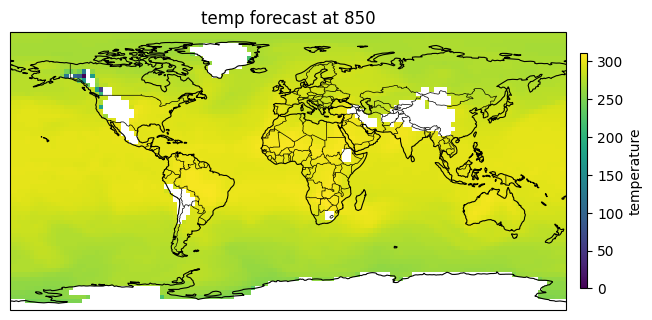

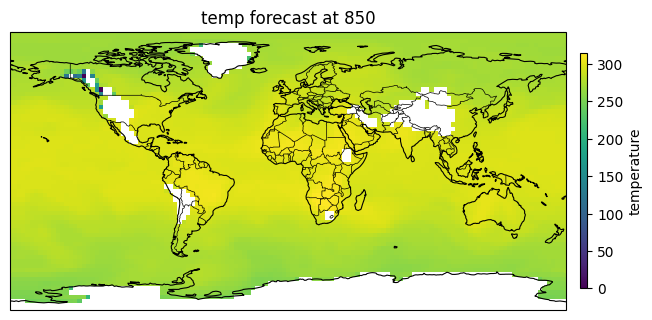

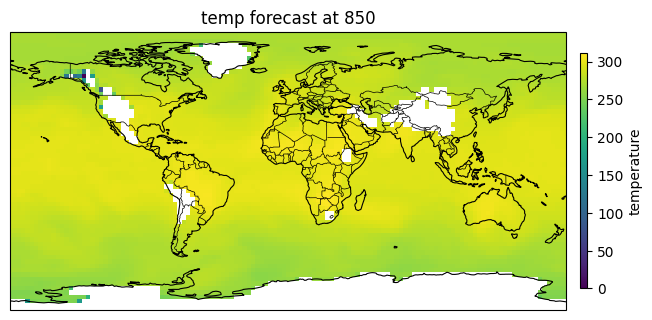

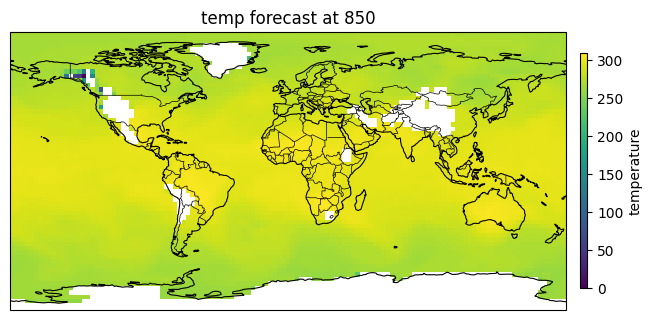

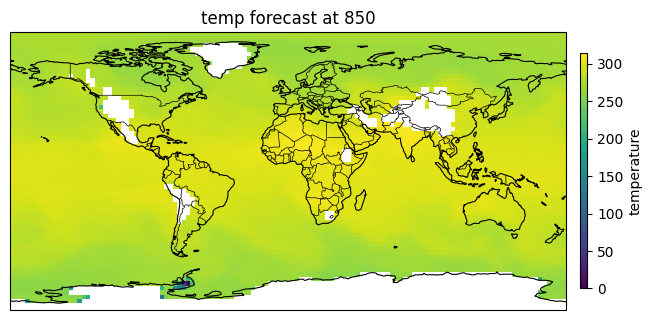

In [12]:
for t in min_coords.time:
    plot.plot_single_plot(truth.sel(time=t).where(mask_sel).T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)

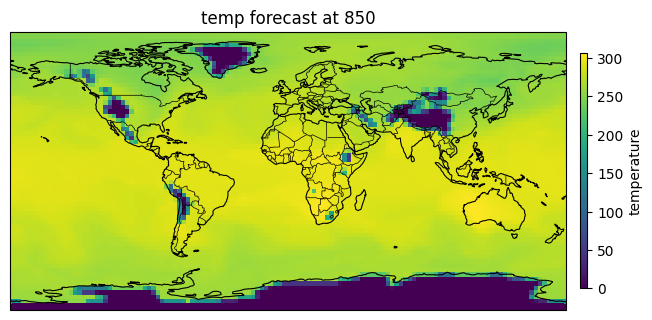

In [17]:
plot.plot_single_plot(ukesm_historical_truth_equiangular_wp_cons.isel(time=-1).sel(level=plevel)[variable].T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)

In [18]:
print(ukesm_historical_truth_equiangular_wp_cons.sel(level=plevel)[variable])

<xarray.DataArray 'temperature' (time: 43199, longitude: 128, latitude: 64)> Size: 1GB
dask.array<getitem, shape=(43199, 128, 64), dtype=float32, chunksize=(40, 128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
    level      float32 4B 850.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
  * time       (time) object 346kB 1985-01-01 06:00:00 ... 2014-12-30 18:00:00
Attributes:
    date:           01/01/50
    long_name:      Temperature T
    name:           temp
    source:         Unified Model Output (Vn10.9):
    standard_name:  air_temperature
    time:           00:00
    title:          Temperature T
    units:          K
    valid_max:      312.37158203125
    valid_min:      0.0


[200. 300. 500. 700. 850. 925.]


In [46]:
plevel = 700
mask_threshold=plot.MASK_VALUES_UKESM_TEMPERATURE[str(plevel)]
truth = ds_test_truth.sel(level=plevel)[variable].isel(time=12*60)
forecast=ds_test_forecast.sel(level=plevel)[variable].isel(time=12*60)
plot.plot_single_plot(truth.where(truth >= mask_threshold).T, f'temp at {plevel}', 'temperature', (mask_threshold,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test')
plot.plot_single_plot(forecast.where(truth >= mask_threshold).T, f'temp forecast at {plevel}', 'temperature', (mask_threshold,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_forecast')

In [55]:
print(ds_test_truth.level.values)
plevel = 850

[200. 300. 500. 700. 850. 925.]


In [67]:
lowest_temp = ukesm_future_truth_equiangular_wp_cons.sel(level=plevel)[variable].min(dim='time')
print(lowest_temp)
plot.plot_single_plot(lowest_temp.T, f'Lowest temperature per coordinate at {plevel}hPa', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'lowest_temp_val_850')

<xarray.DataArray 'temperature' (longitude: 128, latitude: 64)> Size: 33kB
dask.array<_nanmin_skip-aggregate, shape=(128, 64), dtype=float32, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
    level      float32 4B 850.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2


In [68]:
from tqdm import tqdm
experiment = lowest_temp.where(lowest_temp >= mask_threshold).copy()
print(experiment.values.shape)
vals = experiment.values

plot.plot_single_plot(experiment.T, f'Lowest temperature per coordinate at {plevel}hPa (Impossible masked out)', 'temperature', (mask_threshold,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'lowest_temp_val_850_impossible_masked')

(128, 64)


In [62]:
shifted_1 = experiment.isel(longitude=slice(0,-1))
shifted_2 = experiment.isel(longitude=slice(1,None))
shifted_2['longitude'] = shifted_1.longitude
diff=(shifted_1-shifted_2)
# pad diff to match experiment dims
pad_lat = experiment.latitude.size - diff.latitude.size
pad_lon = experiment.longitude.size - diff.longitude.size
# plot.plot_single_plot(diff.T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)

diff_padded = xr.concat(
    [xr.full_like(diff.isel(latitude=slice(-pad_lat, None), longitude=slice(-pad_lon, None)), -70), diff],
    dim='longitude'
)


diff_padded_left = diff_padded.fillna(0)
diff_padded_left['longitude'] = truth.longitude
# plot.plot_single_plot(experiment.T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)
# plot.plot_single_plot(experiment.where(diff_padded_left<20).T, f'temp forecast at {plevel}', 'temperature', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_experiment', show=True)

In [63]:
shifted_1 = experiment.isel(longitude=slice(0,-1))
shifted_2 = experiment.isel(longitude=slice(1,None))
shifted_1['longitude'] = shifted_2.longitude
diff=(shifted_2-shifted_1)
# pad diff to match experiment dims
pad_lat = experiment.latitude.size - diff.latitude.size
pad_lon = experiment.longitude.size - diff.longitude.size

diff_padded = xr.concat(
    [diff, xr.full_like(diff.isel(latitude=slice(-pad_lat, None), longitude=slice(-pad_lon, None)), -70)],
    dim='longitude'
)


diff_padded_right = diff_padded.fillna(0)
diff_padded_right['longitude'] = truth.longitude

In [64]:
# Shift experiment data up and down along latitude
shifted_up = experiment.isel(latitude=slice(0, -1))   # all except last latitude
shifted_down = experiment.isel(latitude=slice(1, None))  # all except first latitude
shifted_down['latitude'] = shifted_up.latitude  # align coordinates

# Compute difference between neighboring latitude bands
diff_lat = shifted_up - shifted_down

# Pad diff_lat to match experiment dimensions
pad_lat = experiment.latitude.size - diff_lat.latitude.size
pad_lon = experiment.longitude.size - diff_lat.longitude.size



# Pad along latitude to restore full grid
diff_lat_padded = xr.concat(
    [xr.full_like(diff_lat.isel(latitude=slice(-pad_lat, None)), -70), diff_lat],
    dim='latitude'
)

# Replace NaNs and realign coordinates
diff_padded_down = diff_lat_padded.fillna(0)
diff_padded_down['latitude'] = truth.latitude


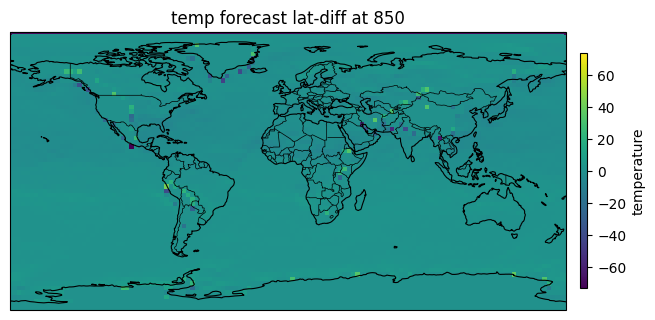

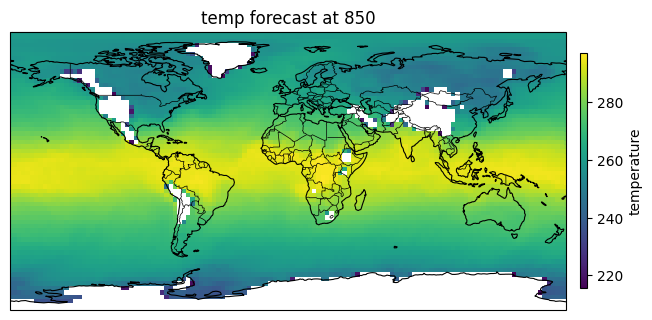

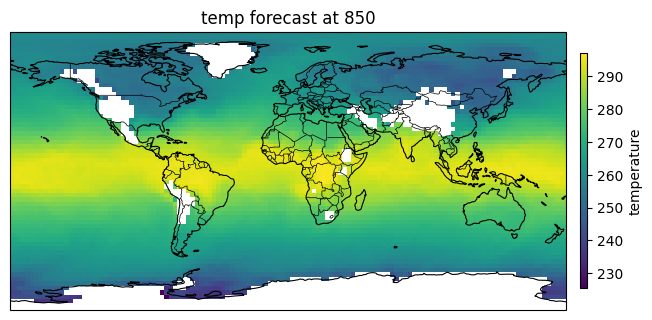

In [69]:
# Shift experiment data up and down along latitude
shifted_up = experiment.isel(latitude=slice(0, -1))   # all except last latitude
shifted_down = experiment.isel(latitude=slice(1, None))  # all except first latitude
shifted_up['latitude'] = shifted_down.latitude  # align coordinates

# Compute difference between neighboring latitude bands
diff_lat = shifted_down - shifted_up

# Pad diff_lat to match experiment dimensions
pad_lat = experiment.latitude.size - diff_lat.latitude.size
pad_lon = experiment.longitude.size - diff_lat.longitude.size



# Pad along latitude to restore full grid
diff_lat_padded = xr.concat(
    [diff_lat,xr.full_like(diff_lat.isel(latitude=slice(-pad_lat, None)), -70)],
    dim='latitude'
)

# Replace NaNs and realign coordinates
diff_padded_up = diff_lat_padded.fillna(0)
diff_padded_up['latitude'] = truth.latitude

# Plot the difference field (optional diagnostic)
plot.plot_single_plot(
    diff_padded_up.T,
    f'temp forecast lat-diff at {plevel}',
    'temperature',
    None,
    'viridis',
    "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/",
    'test_experiment_latdiff',
    show=True
)

# Plot original and filtered results
plot.plot_single_plot(
    experiment.T,
    f'temp forecast at {plevel}',
    'temperature',
    None,
    'viridis',
    "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/",
    'test_experiment_lat',
    show=True
)
thresh=15
temp_mask = experiment.where(diff_padded_up < thresh).where(diff_padded_down < thresh).where(diff_padded_left < thresh).where(diff_padded_right < thresh)
plot.plot_single_plot(
    temp_mask.T,
    f'temp forecast at {plevel}',
    'temperature',
    None,
    'viridis',
    "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/",
    'test_experiment_lat_filtered',
    show=True
)
thresh=10
temp_mask = experiment.where(diff_padded_up < thresh).where(diff_padded_down < thresh).where(diff_padded_left < thresh).where(diff_padded_right < thresh)
plot.plot_single_plot(
    temp_mask.T,
    f'Lowest temperature per coordinate at {plevel}hPa (Impossible masked out and filtered)',
    'temperature',
    None,
    'viridis',
    "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/",
    'lowest_temp_val_850_impossible_masked_and_filtered_thresh_10'
)

In [51]:
ds = xr.open_dataset("valid_mask.zarr")
mask2 = ds[f'temperature_{plevel}']

In [54]:

mask = xr.where(temp_mask.notnull(), 1, 0)  # 1 = valid, 0 = invalid
# combined_mask = mask * mask2
# plot.plot_single_plot(
#     combined_mask.T,
#     f'temp forecast at {plevel}',
#     'temperature',
#     None,
#     'viridis',
#     "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/",
#     'test_experiment_lat_filtered',
#     show=True
# )
combined_mask = mask 
combined_mask = combined_mask.drop_vars(["level"])

combined_mask = combined_mask.chunk(longitude=-1, latitude=-1)
print(combined_mask)
combined_mask.to_dataset(name=f"temperature_{plevel}").to_zarr(f"combined_valid_mask.zarr_future", mode='a')

<xarray.DataArray 'temperature' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<rechunk-merge, shape=(128, 64), dtype=int64, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
    time       object 8B 2098-01-11 06:00:00


In [37]:
print(plevel)

850


In [53]:
ds = xr.open_dataset("combined_valid_mask.zarr")
print(ds)

<xarray.Dataset> Size: 198kB
Dimensions:          (latitude: 64, longitude: 128)
Coordinates:
  * latitude         (latitude) float64 512B -90.0 -87.14 -84.29 ... 87.14 90.0
  * longitude        (longitude) float64 1kB 0.0 2.812 5.625 ... 354.4 357.2
Data variables:
    temperature_700  (longitude, latitude) int64 66kB ...
    temperature_850  (longitude, latitude) int64 66kB ...
    temperature_925  (longitude, latitude) int64 66kB ...


In [20]:
make_nan = []
for ilon in tqdm(range(experiment.values.shape[0]-1)):
    for ilat in range(experiment.values.shape[1]-1):
        p1 = experiment.values[ilon][ilat]
        p2 = experiment.values[ilon][ilat+1]
        p3 = experiment.values[ilon+1][ilat]
        if not p1==np.nan and not p2==np.nan:
            if p1-p2 > 20:
                make_nan.append((ilon,ilat+1))
            elif p2-p1 > 20:
                make_nan.append((ilon,ilat))
        if not p1==np.nan and not p3==np.nan:
            if p1-p3 > 20:
                make_nan.append((ilon+1,ilat))
            elif p3-p1 > 20:
                make_nan.append((ilon,ilat))


100%|██████████| 127/127 [04:02<00:00,  1.91s/it]


In [26]:
make_nan=true_make_nan

In [32]:
for p in true_make_nan:
    print(p)
    experiment.isel(latitude=p[1], longitude=p[0]).values[...] = np.nan
plot.plot_single_plot(experiment.T, f'temp at {plevel}', 'temperature', (mask_threshold,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'experiment')

(13, 36)
(13, 36)
(14, 45)
(14, 36)
(14, 36)
(14, 45)
(16, 44)
(17, 8)
(16, 44)
(17, 43)
(16, 46)
(16, 46)
(17, 8)
(17, 43)
(18, 42)
(17, 45)
(17, 45)
(18, 42)
(20, 43)
(20, 43)
(21, 8)
(22, 43)
(22, 44)
(22, 8)
(22, 43)
(22, 44)
(24, 42)
(24, 45)
(24, 7)
(24, 7)
(24, 42)
(24, 42)
(24, 45)
(26, 47)
(26, 43)
(27, 42)
(26, 47)
(27, 42)
(27, 47)
(29, 8)
(29, 41)
(29, 8)
(30, 8)
(29, 41)
(30, 41)
(30, 49)
(30, 8)
(30, 41)
(30, 49)
(31, 48)
(30, 49)
(31, 50)
(31, 8)
(31, 47)
(31, 46)
(31, 47)
(31, 47)
(31, 50)
(33, 46)
(33, 47)
(32, 50)
(32, 50)
(34, 50)
(35, 40)
(34, 50)
(35, 40)
(36, 46)
(36, 50)
(36, 50)
(37, 47)
(37, 47)
(38, 41)
(38, 43)
(38, 43)
(41, 8)
(42, 8)
(43, 8)
(44, 8)
(45, 8)
(51, 8)
(86, 49)
(86, 49)
(87, 48)
(86, 49)
(87, 44)
(88, 44)
(87, 49)
(87, 50)
(88, 44)
(89, 5)
(90, 40)
(89, 48)
(89, 48)
(90, 5)
(90, 40)
(91, 5)
(92, 38)
(92, 5)
(92, 38)
(93, 5)
(93, 39)
(93, 39)
(98, 5)
(98, 5)
(100, 28)
(100, 28)
(100, 28)
(103, 20)
(104, 27)
(104, 27)
(105, 22)
(105, 22)
(106, 24

In [ ]:
mask = xr.where(experiment.notnull(), 1, 0)  # 1 = valid, 0 = invalid
mask.to_zarr(f"valid_mask_{plevel}hPa.zarr")

In [20]:
plot.plot_single_plot(ds_test_truth['surface_temperature'].isel(time=6*60).T, f'temp at surface', 'temperature', (0,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_surf')
plot.plot_single_plot(ds_test_forecast['surface_temperature'].isel(time=6*60).T, f'temp forecast at surface', 'temperature', (0,350), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", 'test_forecast_surf')

In [ ]:
all_performance_1819 = []
all_performance_2049 = []
all_shift_map_2049 = []
all_relative_performance_error = []
all_absolute_performance_error = []
all_relative_performance_percentage = []
all_mean_truth_difference=[]
weighted_wasserstein = []
weighted_rmse_list = []
all_truth_201819 = []
all_truth_2049 = []
all_forecast_201819 = []
all_forecast_2049 = []

mixed = False
historical_year='2019'
future_year='2049'
error_after_hours = 120 # Must be dividable by 6


assert (error_after_hours % 6) == 0 and error_after_hours > 0
error_after_x_steps = int(error_after_hours / 6) - 1

# First prediction is always at 00 or 12 -> if error_after_x_steps is odd, we only look at 00 and 12 time values 
# If not, we only look at 06 and 18 time values
if error_after_x_steps % 2 == 0:
    filter_hours = [6,18]
else: filter_hours = [0,12]

if mixed:
    base_save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_try2_z64/plots/"
else:
    # base_save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z64/plots/"
    base_save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/trained_models/nextgems_1990_2020_6h-128x64_equiangular_with_poles_conservative_z128/plots/"

for display_name, unit, variable, plevel in plot.KEY_VARIABLES:
    
    
    if mixed:
        truth_hist = nextgems_mixed_truth_1819.sel(time=historical_year).isel(time=slice(0,-1))[variable]
        truth_future = nextgems_mixed_truth_49.sel(time=future_year)[variable]
        forecast_hist = nextgems_1990_2020_mixed_z64.sel(time=historical_year)[variable].sel(time=nextgems_1990_2020_mixed_z64.time.dt.hour.isin([0, 12])).isel(time=slice(10,-10))
        forecast_future = nextgems_2049_mixed_z64.sel(time=future_year)[variable].sel(time=nextgems_2049_mixed_z64.time.dt.hour.isin([0, 12])).isel(time=slice(10,-10))
    else:
        truth_hist = nextgems_equiangular_wp_cons_truth_1819.sel(time=historical_year)[variable]
        truth_hist = truth_hist.isel(time=slice(2+error_after_x_steps,-(38-error_after_x_steps)))
        truth_hist = truth_hist.sel(time=truth_hist.time.dt.hour.isin(filter_hours))
        truth_future = nextgems_equiangular_wp_cons_truth_49.sel(time=future_year)[variable]
        truth_future = truth_future.isel(time=slice(2+error_after_x_steps,-(38-error_after_x_steps)))
        truth_future = truth_future.sel(time=truth_future.time.dt.hour.isin(filter_hours))
        forecast_hist = nextgems_1990_2020_equiangular_wp_cons_z128.sel(time=historical_year)[variable].isel(prediction_timedelta=error_after_x_steps)
        forecast_future = nextgems_2049_equiangular_wp_cons_z128.sel(time=future_year)[variable].isel(prediction_timedelta=error_after_x_steps)
        print(forecast_hist['time'])
        print(truth_hist['time'])
        forecast_hist['time'] = truth_hist['time']
        forecast_future['time'] = truth_future['time']
        
        
    if plevel:
        truth_hist = truth_hist.sel(level=plevel)
        truth_future = truth_future.sel(level=plevel)
        forecast_hist = forecast_hist.sel(level=plevel)
        forecast_future = forecast_future.sel(level=plevel)
        
    

    all_truth_201819.append(truth_hist)
    all_truth_2049.append(truth_future)
    all_forecast_201819.append(forecast_hist)
    all_forecast_2049.append(forecast_future)
    performance_1819 = rmse(truth_hist, forecast_hist)
    performance_2049 = rmse(truth_future, forecast_future)
    all_relative_performance_percentage.append((performance_2049 - performance_1819) / performance_1819 * 100)
    all_performance_1819.append(performance_1819)
    all_performance_2049.append(performance_2049)
    all_shift_map_2049.append(shift_per_gridcell(truth_hist, truth_future))
    weighted_wasserstein.append(shift_global(truth_hist, truth_future))
    weighted_rmse_1819 = weighted_rmse(truth_hist, forecast_hist)
    weighted_rmse_49 = weighted_rmse(truth_future, forecast_future)
    weighted_rmse_list.append((weighted_rmse_49 - weighted_rmse_1819) / weighted_rmse_1819 * 100)
    all_relative_performance_error.append(performance_2049 / performance_1819)
    all_absolute_performance_error.append(performance_2049 - performance_1819)
    all_mean_truth_difference.append(truth_future.mean('time') - truth_hist.mean('time'))

<xarray.DataArray 'time' (time: 710)> Size: 6kB
array(['2019-01-01T06:00:00.000000000', '2019-01-01T18:00:00.000000000',
       '2019-01-02T06:00:00.000000000', ..., '2019-12-20T18:00:00.000000000',
       '2019-12-21T06:00:00.000000000', '2019-12-21T18:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000120
  * time                  (time) datetime64[ns] 6kB 2019-01-01T06:00:00 ... 2...
<xarray.DataArray 'time' (time: 710)> Size: 6kB
array(['2019-01-06T12:00:00.000000000', '2019-01-07T00:00:00.000000000',
       '2019-01-07T12:00:00.000000000', ..., '2019-12-26T00:00:00.000000000',
       '2019-12-26T12:00:00.000000000', '2019-12-27T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 6kB 2019-01-06T12:00:00 ... 2019-12-27
<xarray.DataArray 'time' (time: 710)> Size: 6kB
array(['2019-01-01T06:00:00.000000000', '2019-01-01T18:00:00.000000000',
       '2019-01-02T06:00:00.

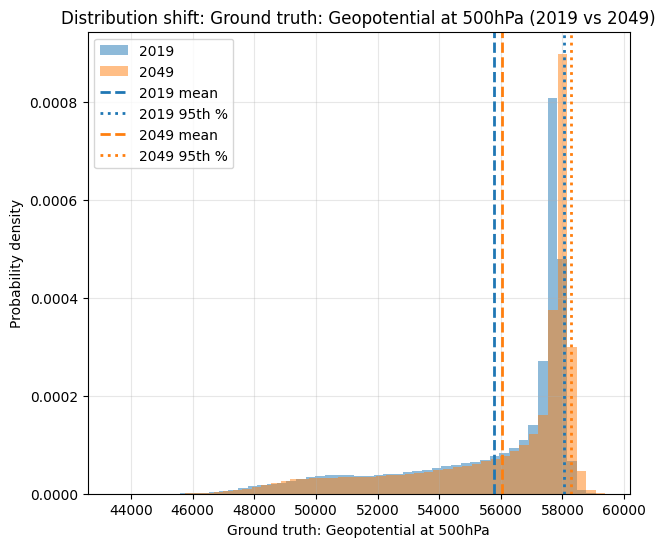

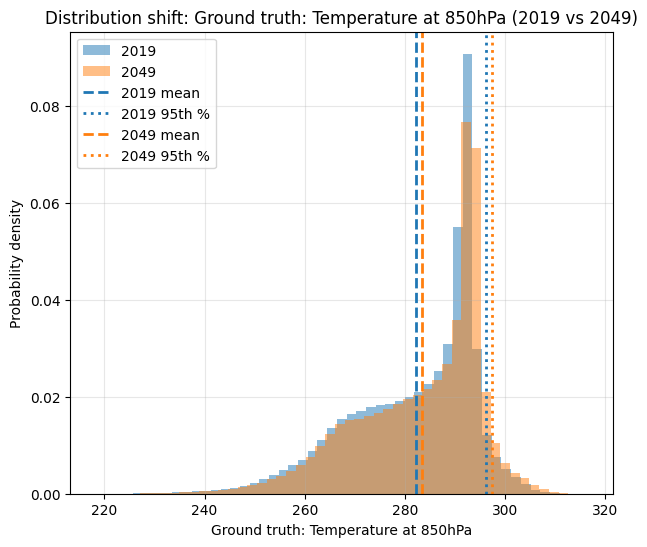

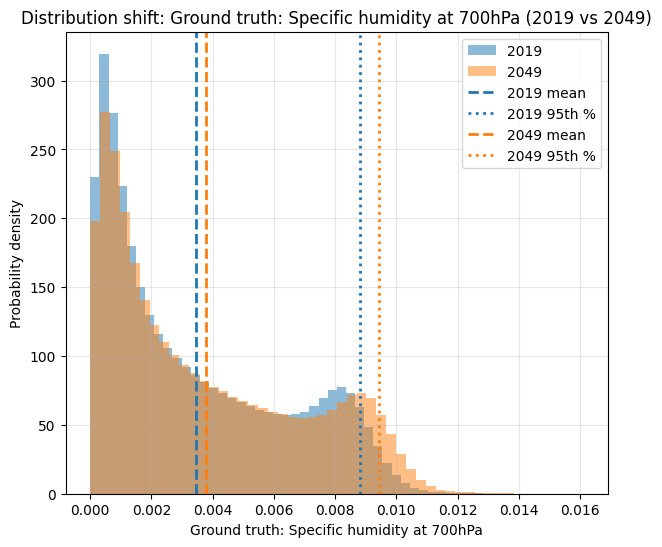

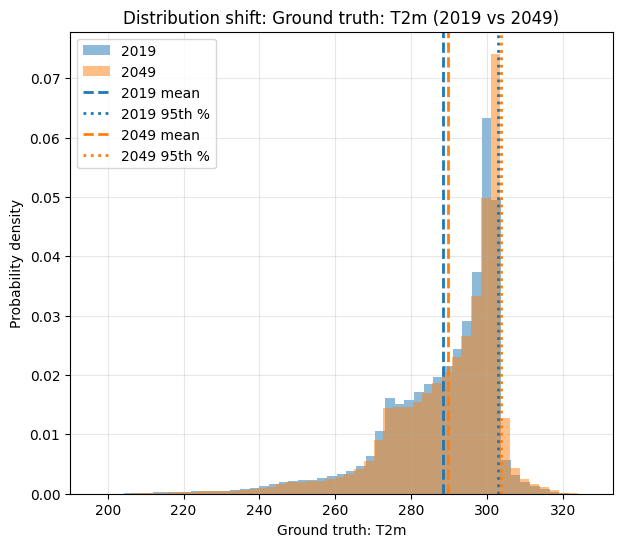

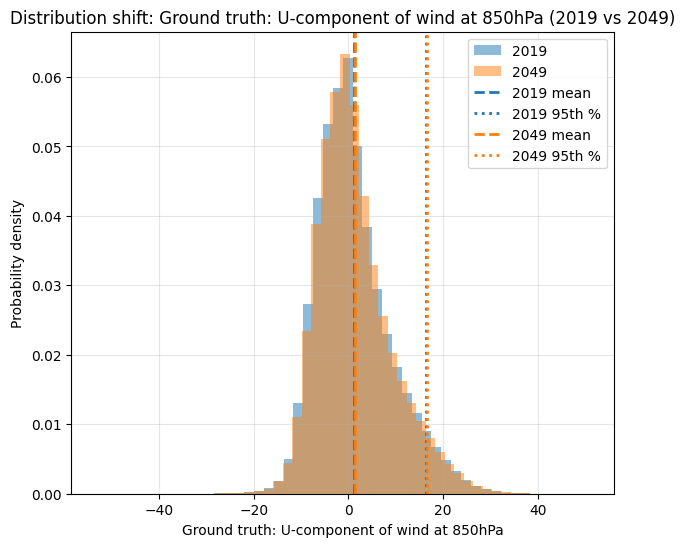

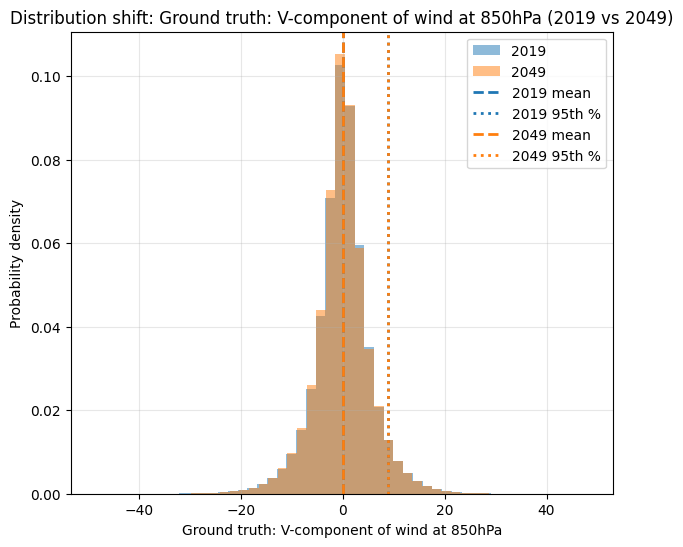

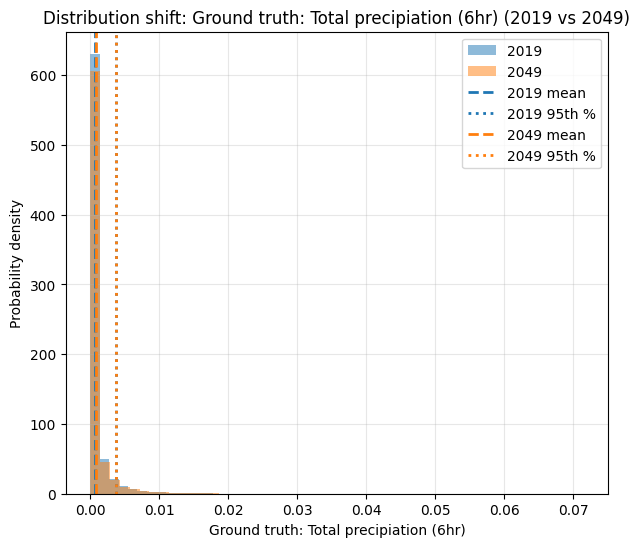

In [15]:
# Zonally weighted
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plot_distributions(all_truth_201819[i], all_truth_2049[i], variable_name='Ground truth: '+ display_name, save_to=base_save_folder + f'truth_distribution_shift/{display_name.replace(" ", "_")}_zonally_weighted.png')

In [16]:
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    plot.plot_zonal_plot(
        all_mean_truth_difference[i],
        title=f"Absolute difference in {display_name} (2049 vs 2019)",
        y_label=f"Absolute difference (2049 / 2019) in {unit}",
        #vbounds=(-max_val,max_val),
        base_save_folder=base_save_folder+"zonal_average_shift/",
        save_name=f"zonal_truth_difference_{variable}{plevel_display.replace(' ', '_')}",
        label_below="Value decrease (in 2049)",
        label_above="Value increase (in 2049)",
        centered_around=0,
        color_above='green',
        color_below='red'
    )

In [17]:
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    plot.plot_zonal_plot(
        all_relative_performance_percentage[i],
        title=f"Zonal mean of relative performance error after {error_after_x_steps} steps (2049 vs 2019)\n{display_name}",
        y_label="Relative RMSE (2049 - 2019) / 2019 in %",
        centered_around=0,
        base_save_folder=base_save_folder+"zonal_relative_performance/",
        save_name=f"zonal_relative_performance_percentage_{variable}{plevel_display.replace(' ', '_')}_after{error_after_x_steps}steps"
    )


In [27]:
plt.figure(figsize=(7,6))
plt.scatter(weighted_wasserstein, weighted_rmse_list)
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    # Annotate each variable
    plt.text(weighted_wasserstein[i]*1.01, weighted_rmse_list[i]*1.01, display_name)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Wasserstein distance (normalized, area-weighted)")
plt.xlim(0, max(weighted_wasserstein) * 1.7)
plt.ylabel("Performance degradation (%)")
plt.title("Model robustness: 2049 vs 2019 (weighted)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(base_save_folder+"relative_performance_degradation_per_normalized_wasserstein_distance_.png", dpi=300)
plt.close()

### Local RMSE per Wasserstein distance

Computing the Wasserstein distance between the distribution per gridpoint over 2049 and the global distribution in 2049.
Plot the local RMSE per grid point after x steps onto the local Wasserstein distance.

In [19]:
index = 1

gt = all_truth_2049[index].astype(np.float32).load()  # (time, lon, lat)
sim_sel = all_forecast_2049[index].astype(np.float32).load()   # (time, lon, lat)
relative_rmse_difference = (all_performance_2049[index]-all_performance_1819[index])/all_performance_1819[index]
true_data_mean = all_truth_2049[index].mean(dim='time')
true_data_mean_19 = all_truth_201819[index].mean(dim='time') 

display_name, unit, variable, plevel = plot.KEY_VARIABLES[index]
plevel_display = f' at {plevel}hPa' if plevel else ' at surface'

In [12]:
from joblib import Parallel, delayed
import numpy as np
import xarray as xr
from tqdm import tqdm

gt_vals = gt.values
sim_vals = sim_sel.values

# --- Latitude weights ---
lats = gt["latitude"].values
w_lat = np.cos(np.deg2rad(lats))
w_lat = w_lat / w_lat.mean()

# Broadcast weights to (time, lon, lat)
W = xr.DataArray(
    np.broadcast_to(w_lat[np.newaxis, np.newaxis, :],
                    gt.shape),
    coords=gt.coords, dims=gt.dims
)

# Precompute flattened global distribution
vals_global = gt_vals.flatten()
wg_global   = W.values.flatten()

mask_global = np.isfinite(vals_global)
vals_global = vals_global[mask_global]
wg_global   = wg_global[mask_global]

# Convert coords to plain floats (important for joblib!)
lons = gt.longitude.values.astype(float)
lats = gt.latitude.values.astype(float)
points = [(lon, lat) for lon in lons for lat in lats]
lon_index = {lon: i for i, lon in enumerate(gt.longitude.values)}
lat_index = {lat: j for j, lat in enumerate(gt.latitude.values)}

some_local_gt = gt_vals[:, 0, 0]
w_local = np.ones_like(some_local_gt)

def process_point(lon, lat):
    # Extract raw NumPy arrays (avoids slow .sel each call)
    i, j = lon_index[lon], lat_index[lat]
    local_gt = gt_vals[:, i, j]    
    local_sim = sim_vals[:, i, j]  

    ws = float(weighted_wasserstein_1d(local_gt, vals_global, w_local, wg_global))
    rmse = float(np.sqrt(np.mean((local_sim - local_gt) ** 2)))
    return ws, rmse

# Parallel loop
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(process_point)(lon, lat) for lon, lat in tqdm(points)
)

# Convert results directly to arrays for plotting
results = np.array(results)   # shape (npoints, 2)
ws_distances = results[:, 0]
rmses = results[:, 1]


100%|██████████| 8192/8192 [07:55<00:00, 17.22it/s]


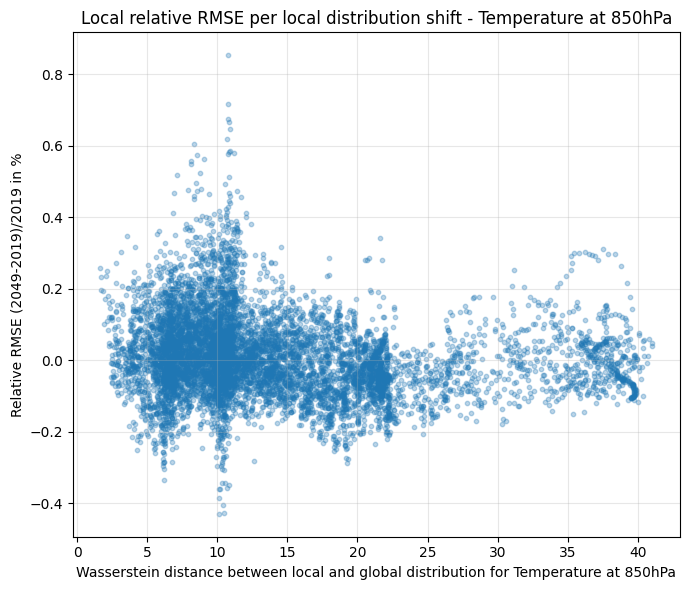

In [13]:
plt.figure(figsize=(7,6))
plt.scatter(ws_distances, relative_rmse_difference, alpha=0.3, s=10)
plt.xlabel(f"Wasserstein distance between local and global distribution for {display_name}")
plt.ylabel("Relative RMSE (2049-2019)/2019 in %")
plt.title(f"Local relative RMSE per local distribution shift - {display_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(base_save_folder+variable+f"/rel_rmse_per_local_to_global_wasserstein_point_{variable}{plevel_display.replace(' ', '_')}.png", dpi=300)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from importlib import reload
reload(plot)
import plot_utils as plot 

# Get lon/lat coordinates
lons = gt.longitude.values
lats = gt.latitude.values

# Reshape 1D arrays into 2D grids
n_lon = len(lons)
n_lat = len(lats)

ws_grid = np.reshape(ws_distances, (n_lon, n_lat))   
rmse_grid = np.reshape(rmses, (n_lon, n_lat))       

ws_ds = xr.Dataset(
            {variable: (('longitude','latitude'), ws_grid)},
            coords={
        "latitude": lats,
        "longitude": lons,
    })

# Optional: flip latitude if needed for plotting
if lats[0] > lats[-1]:
    ws_grid = ws_grid[::-1, :]
    rmse_grid = rmse_grid[::-1, :]
    lats = lats[::-1]

plot.plot_double_plot(data_left=ws_ds[variable].T,
                 title_left=f"Distribution shift (Wasserstein, 2049 local to global)\n{display_name}",
                 cbar_label_left="Distribution shift",
                 vbounds_left=None,
                 cmap_left="Reds",
                 data_right=true_data_mean.T,
                 title_right=f"Yearly average (2049)\n{display_name}",
                 cbar_label_right=unit,
                 vbounds_right=None,
                 cmap_right="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=variable+f"/local_to_global_wasserstein_and_yearly_average_{variable}{plevel_display.replace(' ', '_')}")

                
# plot_map(all_truth_2049[0].mean(dim='time'), lons, lats, title="Ground truth 49")
plot.plot_single_plot(data_left=relative_rmse_difference.T,
                 title_left=f"Relative RMSE difference (2049-2019)/2019 after {error_after_x_steps} steps",
                 cbar_label_left="Relative RMSE difference in %",
                 vbounds_left=None,
                 cmap_left="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=variable+f"/relative_rmse_2049_to_2019_after_{error_after_x_steps}steps_{variable}{plevel_display.replace(' ', '_')}")
plot.plot_single_plot(data_left=(true_data_mean - true_data_mean_19).T,
                 title_left=f"Mean value difference (2049-2019)",
                 cbar_label_left=f"Mean difference in {unit}",
                 vbounds_left=None,
                 cmap_left="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=variable+f"/mean_value_difference_2049_to_2019_{variable}{plevel_display.replace(' ', '_')}")


NameError: name 'ws_distances' is not defined

In [ ]:
lats = truth_hist['latitude'].values
w_lat = np.cos(np.deg2rad(lats))
print(w_lat)

[6.12323400e-17 4.98458857e-02 9.95678466e-02 1.49042266e-01
 1.98146143e-01 2.46757398e-01 2.94755174e-01 3.42020143e-01
 3.88434796e-01 4.33883739e-01 4.78253979e-01 5.21435203e-01
 5.63320058e-01 6.03804410e-01 6.42787610e-01 6.80172738e-01
 7.15866849e-01 7.49781203e-01 7.81831482e-01 8.11938006e-01
 8.40025923e-01 8.66025404e-01 8.89871809e-01 9.11505852e-01
 9.30873749e-01 9.47927346e-01 9.62624247e-01 9.74927912e-01
 9.84807753e-01 9.92239207e-01 9.97203797e-01 9.99689182e-01
 9.99689182e-01 9.97203797e-01 9.92239207e-01 9.84807753e-01
 9.74927912e-01 9.62624247e-01 9.47927346e-01 9.30873749e-01
 9.11505852e-01 8.89871809e-01 8.66025404e-01 8.40025923e-01
 8.11938006e-01 7.81831482e-01 7.49781203e-01 7.15866849e-01
 6.80172738e-01 6.42787610e-01 6.03804410e-01 5.63320058e-01
 5.21435203e-01 4.78253979e-01 4.33883739e-01 3.88434796e-01
 3.42020143e-01 2.94755174e-01 2.46757398e-01 1.98146143e-01
 1.49042266e-01 9.95678466e-02 4.98458857e-02 6.12323400e-17]


In [22]:
print(all_relative_performance_percentage)

[<xarray.DataArray 'geopotential' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<mul, shape=(128, 64), dtype=float64, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
    level                 int64 8B 500
  * longitude             (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000120, <xarray.DataArray 'temperature' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<mul, shape=(128, 64), dtype=float64, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude              (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
    level                 int64 8B 850
  * longitude             (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
    prediction_timedelta  timedelta64[ns] 8B 00:00:00.000000120, <xarray.DataArray 'specific_humidity' (longitude: 128, latitude: 64)> Size: 66kB
dask.array<mul, shape=(128, 64), dtyp

In [23]:
calculated_rmse = [(x.mean(dim="longitude") * w_lat).sum() / w_lat.sum() for x in all_relative_performance_percentage]

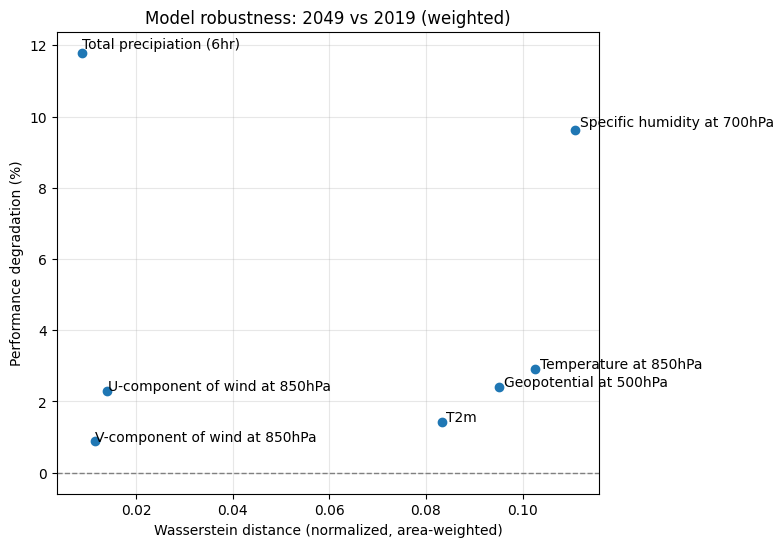

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(weighted_wasserstein, calculated_rmse)
for i, (display_name, unit, variable, plevel) in enumerate(plot.KEY_VARIABLES):
    plevel_display = f' at {plevel}hPa' if plevel else ' at surface'
    # Annotate each variable
    plt.text(weighted_wasserstein[i]*1.01, calculated_rmse[i]*1.01, display_name)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Wasserstein distance (normalized, area-weighted)")
plt.xlim(max(weighted_wasserstein)*1.7)
plt.ylabel("Performance degradation (%)")
plt.title("Model robustness: 2049 vs 2019 (weighted)")
plt.grid(True, alpha=0.3)
plt.savefig(base_save_folder+"relative_performance_degradation_per_normalized_wasserstein_distance.png", dpi=300)

In [9]:

plot.plot_double_plot(data_left=shift_map_2049.T,
                 title_left=f"Distribution shift (Wasserstein, 2049 vs 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_left="Distribution shift",
                 vbounds_left=None,
                 cmap_left="Reds",
                 data_right=relative_performance_error.T,
                 title_right=f"Relative performance degradation (RMSE 2049 / 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_right="Relative performance degradation",
                 vbounds_right=(0.3, 1.7),
                 cmap_right="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=f'shift_relative_performance_{info_to_save}')

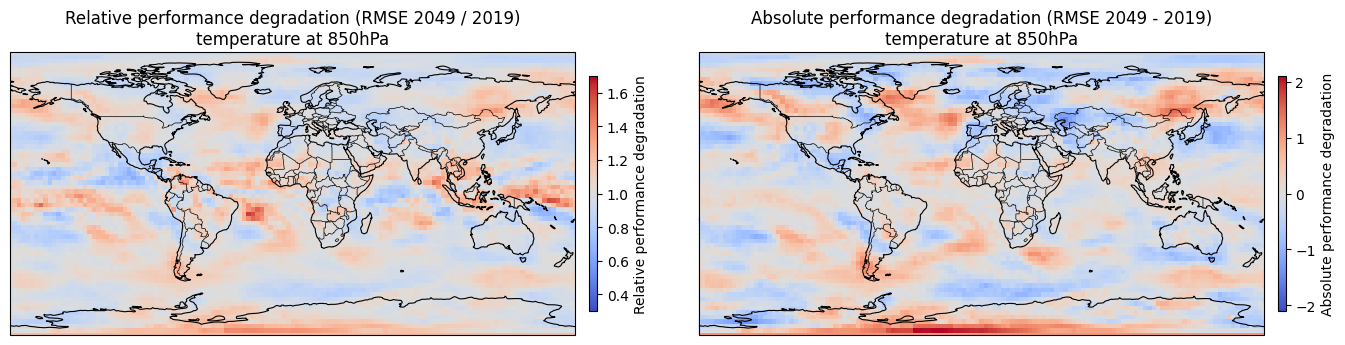

In [ ]:

plot.plot_double_plot(data_left=relative_performance_error.T,
                 title_left=f"Relative performance degradation (RMSE 2049 / 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_left="Relative performance degradation",
                 vbounds_left=(0.3, 1.7),
                 cmap_left="coolwarm",
                 data_right=absolute_performance_error.T,
                 title_right=f"Absolute performance degradation (RMSE 2049 - 2019)\n{variable}{f' at {plevel}hPa' if plevel else ''}",
                 cbar_label_right="Absolute performance degradation",
                 vbounds_right=None,
                 cmap_right="coolwarm",
                 base_save_folder=base_save_folder,
                 save_name=f"absolute_relative_performance_{info_to_save}")

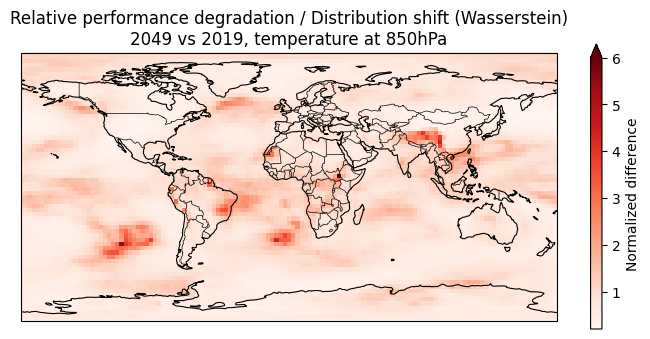

In [62]:
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 1, figsize=(7,6), subplot_kw={"projection": proj})
(relative_performance_error / shift_map_2049).T.plot(ax=axes, cmap="Reds", transform=proj, vmax=6, cbar_kwargs={"shrink": 0.5, "aspect": 25, "label": "Normalized difference"})
axes.add_feature(cfeature.COASTLINE, linewidth=0.8)
axes.add_feature(cfeature.BORDERS, linewidth=0.5)
axes.set_title(f"Relative performance degradation / Distribution shift (Wasserstein)\n2049 vs 2019, {variable}{f' at {plevel}hPa' if plevel else ''}")

plt.tight_layout()
plt.savefig(base_save_folder+f"normalized_performance_degradation_{info_to_save}.png", dpi=300, bbox_inches='tight')